# Training YOLO v11

This notebook trains a YOLOv11 object detector on the TACO dataset using the reduced 17-class taxonomy developed in the earlier experiments. It covers dataset conversion, progressively longer training runs, checkpoint comparison, reproducible validation, and visual analysis of the learning curves and predictions.

Training is deliberately staged. A smoke test verifies the complete pipeline, a pilot run tests whether additional optimization improves the detector, and a longer continuation run searches for the best checkpoint with early stopping.

In [1]:
!nvidia-smi

Wed Jul  8 21:24:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             49W /  400W |    8007MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Install Packages

Install the data-processing, visualization, evaluation, and Ultralytics dependencies required by the notebook. In a fresh Colab runtime, run this cell before importing the packages. A runtime restart may be required if Colab replaces already imported binary dependencies.

In [1]:
!pip install torchmetrics pycocotools gdown tqdm tensorboard albumentations ultralytics

## Import Packages

Import the standard data, numerical, PyTorch, and visualization libraries used throughout the workflow. The random-number generators are seeded immediately afterwards so that the image split and other stochastic operations are reproducible where the underlying CUDA operations permit it.

In [3]:
import os
import pandas as pd
import json

import ast
import os
import torch

import numpy as np
import random
from pathlib import Path
from ultralytics import YOLO

%matplotlib inline

In [4]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [5]:
torch.cuda.current_device()
torch.cuda.get_device_name(0)
device = torch.device("cuda")
device

device(type='cuda')

## Setup Environment

Detect whether the notebook is running in Google Colab and configure paths accordingly. Colab stores persistent outputs in Google Drive, while the non-Colab branch expects the project data under the remote machine's home directory. The following cells also mount Drive and load the processed annotation table or reconstruct it from the source COCO JSON.

In [6]:
def is_google_colab() -> bool:
    """Check whether the notebook is running in Google Colab.
    
    Returns:
        bool: ``True`` in a Colab runtime; otherwise ``False``.
    """
    try:
        import google.colab
        return True
    except ImportError:
        return False


IN_COLAB = is_google_colab()

if IN_COLAB:
    ROOT_PATH = "/content"
    DATAFRAME_PATH = "/content/drive/MyDrive/taco_trash"
    DEFAULT_RUNS_PATH = "/content/drive/MyDrive/taco_trash"
else:
    ROOT_PATH = "/home/ubuntu"
    DATAFRAME_PATH = os.path.join(ROOT_PATH, "taco_trash")
    DEFAULT_RUNS_PATH = os.path.join(ROOT_PATH, "taco_trash")

TACO_CLASSIFICATION_PATH = os.path.join(ROOT_PATH, "taco")

In [5]:
if is_google_colab():
    from google.colab import drive
    drive.mount("/content/drive")
else:
    !curl https://rclone.org/install.sh | sudo bash

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
def parse_bbox(v):
    if isinstance(v, str):
        return ast.literal_eval(v)
    return v
    
if is_google_colab():
    df = pd.read_csv(os.path.join(ROOT_PATH, "annotations_processed.csv"))
else:
    ann_path = os.path.join(TACO_CLASSIFICATION_PATH, "annotations.json")
    with open(ann_path, "r") as f:
        data = json.load(f)

    print(data.keys())

    for key in data.keys():
        if isinstance(data[key], list):
            print(key, len(data[key]))

    df_images = pd.DataFrame(data["images"])
    df_annotations = pd.DataFrame(data["annotations"])
    df_categories = pd.DataFrame(data["categories"])
    df_scene_annotations = pd.DataFrame(data["scene_annotations"])
    df_scene_categories = pd.DataFrame(data["scene_categories"])

    df = df_annotations.merge(
        df_images,
        left_on="image_id",
        right_on="id",
        how="left",
        suffixes=("", "_img"),
    ).merge(
        df_categories,
        left_on="category_id",
        right_on="id",
        how="left",
        suffixes=("", "_cat"),
    ).rename(
        columns={
            "id_x": "annotation_id",
            "id_y": "category_id_full",
            "name": "category_name",
        }
    )
    df['file_path'] = df['file_name'].map(lambda x: os.path.join(TACO_CLASSIFICATION_PATH, x) )

FileNotFoundError: [Errno 2] No such file or directory: '/content/annotations_processed.csv'

## Download Data

Download the TACO image archive and the processed annotation table used by the Colab workflow. The archive is extracted into the runtime's temporary storage for faster training, while model artifacts are written to persistent storage later in the notebook.

In [7]:
!gdown 1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF
!unzip taco.zip -d $ROOT_PATH

Downloading...
From (original): https://drive.google.com/uc?id=1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF
From (redirected): https://drive.google.com/uc?id=1CUxA2TcZFhVJWvNH4qwlOSGDPlxodRPF&confirm=t&uuid=58711afd-06c6-46bb-9a4e-8a22e516296d
To: /content/taco.zip
100% 5.23G/5.23G [00:53<00:00, 97.2MB/s]
Archive:  taco.zip
   creating: /content/content/drive/MyDrive/taco_dataset/taco/
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/annotations.json  
   creating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000011.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000007.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000004.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000000.jpg  
  inflating: /content/content/drive/MyDrive/taco_dataset/taco/batch_14/000014.jpg  
  inflating: /content/content/drive/MyDrive/taco_

In [9]:
!gdown 1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt # annotations_processed.csv

Downloading...
From: https://drive.google.com/uc?id=1lj6H8pIbHjgrgNRWHoc41Nr8bi0FZ7mt
To: /content/annotations_processed.csv
100% 3.10M/3.10M [00:00<00:00, 245MB/s]


## Convert Dataset to YOLO Format

YOLO expects one normalized text annotation file per image and a dataset YAML file describing the train/validation locations and class names. The conversion below maps the original fine-grained TACO labels to 17 broader classes, performs a deterministic image-level 80/20 split, clamps invalid box coordinates, and materializes the corresponding image and label directories.

The split is performed by image rather than annotation. This prevents objects from the same scene appearing in both training and validation data.

In [8]:
MAP_17 = {
    "Aerosol": "Can",
    "Aluminium foil": "Aluminium foil",
    "Battery": "Other",
    "Aluminium blister pack": "Other",
    "Carded blister pack": "Other",
    "Clear plastic bottle": "Plastic bottle",
    "Glass bottle": "Glass bottle",
    "Other plastic bottle": "Plastic bottle",
    "Plastic bottle cap": "Plastic bottle cap",
    "Metal bottle cap": "Metal bottle cap",
    "Broken glass": "Other",
    "Drink can": "Can",
    "Food Can": "Can",
    "Corrugated carton": "Carton",
    "Drink carton": "Carton",
    "Egg carton": "Carton",
    "Meal carton": "Carton",
    "Other carton": "Carton",
    "Paper cup": "Cup",
    "Disposable plastic cup": "Cup",
    "Foam cup": "Cup",
    "Glass cup": "Cup",
    "Other plastic cup": "Cup",
    "Food waste": "Other",
    "Plastic lid": "Plastic lid",
    "Metal lid": "Other",
    "Magazine paper": "Paper",
    "Tissues": "Paper",
    "Wrapping paper": "Paper",
    "Normal paper": "Paper",
    "Paper bag": "Paper",
    "Plastified paper bag": "Paper",
    "Pizza box": "Carton",
    "Garbage bag": "Plastic film",
    "Single-use carrier bag": "Plastic film",
    "Polypropylene bag": "Plastic film",
    "Produce bag": "Plastic film",
    "Cereal bag": "Plastic film",
    "Bread bag": "Plastic film",
    "Plastic film": "Plastic film",
    "Crisp packet": "Wrapper",
    "Other plastic wrapper": "Wrapper",
    "Retort pouch": "Wrapper",
    "Spread tub": "Plastic container",
    "Tupperware": "Plastic container",
    "Disposable food container": "Plastic container",
    "Foam food container": "Plastic container",
    "Other plastic container": "Plastic container",
    "Plastic glooves": "Other",
    "Plastic utensils": "Other",
    "Pop tab": "Pop tab",
    "Rope & strings": "Other",
    "Scrap metal": "Other",
    "Shoe": "Other",
    "Six pack rings": "Plastic film",
    "Squeezable tube": "Other",
    "Plastic straw": "Straw",
    "Paper straw": "Straw",
    "Styrofoam piece": "Styrofoam piece",
    "Toilet tube": "Carton",
    "Unlabeled litter": "Other",
    "Glass jar": "Other",
    "Other plastic": "Other",
    "Cigarette": "Other",
}

In [18]:
import json
import os
from pathlib import Path
import shutil

import torch


def convert_taco_to_yolo(
    taco_dir,
    output_dir,
    category_mapping,
    train_fraction=0.8,
    seed=42,
    image_mode="copy",
    drop_other=False,
):
    """Convert COCO-style TACO annotations to YOLO detection format.

    Args:
        taco_dir (str | Path): Directory containing `annotations.json`
            and the `batch_*` image directories.
        output_dir (str | Path): Destination directory for the YOLO dataset.
        category_mapping (dict[str, str]): Mapping from original TACO
            category names to the reduced taxonomy.
        train_fraction (float): Fraction of images used for training.
        seed (int): Seed for the deterministic image-level split.
        image_mode (str): One of `copy`, `symlink`, or `hardlink`.
        drop_other (bool): Whether to exclude annotations mapped to `Other`.

    Returns:
        Path: Path to the generated `taco.yaml`.
    """
    taco_dir = Path(taco_dir)
    output_dir = Path(output_dir)

    with (taco_dir / "annotations.json").open() as file:
        coco = json.load(file)

    images = {
        int(image["id"]): image
        for image in coco["images"]
    }

    categories = {
        int(category["id"]): category["name"]
        for category in coco["categories"]
    }

    annotations_by_image = {}
    for annotation in coco["annotations"]:
        image_id = int(annotation["image_id"])
        annotations_by_image.setdefault(image_id, []).append(annotation)

    mapped_names = {
        category_mapping.get(name, "Other")
        for name in categories.values()
    }

    if drop_other:
        mapped_names.discard("Other")

    class_names = sorted(mapped_names)
    name_to_id = {
        name: class_id
        for class_id, name in enumerate(class_names)
    }

    category_id_to_yolo_id = {}

    for category_id, category_name in categories.items():
        mapped_name = category_mapping.get(category_name, "Other")

        category_id_to_yolo_id[category_id] = (
            name_to_id.get(mapped_name)
        )

    # This reproduces torch.utils.data.random_split with the same seed.
    image_ids = sorted(images)
    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(
        len(image_ids),
        generator=generator,
    ).tolist()

    train_size = int(train_fraction * len(image_ids))

    train_ids = {
        image_ids[index]
        for index in permutation[:train_size]
    }

    val_ids = {
        image_ids[index]
        for index in permutation[train_size:]
    }

    def materialize_image(source, destination):
        destination.parent.mkdir(parents=True, exist_ok=True)

        if destination.exists() or destination.is_symlink():
            destination.unlink()

        if image_mode == "copy":
            shutil.copy2(source, destination)
        elif image_mode == "hardlink":
            os.link(source, destination)
        elif image_mode == "symlink":
            destination.symlink_to(source.resolve())
        else:
            raise ValueError(f"Unknown image_mode: {image_mode}")

    written_annotations = 0
    skipped_boxes = 0

    for image_id, image in images.items():
        split = "train" if image_id in train_ids else "val"

        relative_path = Path(image["file_name"])
        source_path = taco_dir / relative_path

        image_path = output_dir / "images" / split / relative_path
        label_path = (
            output_dir
            / "labels"
            / split
            / relative_path.with_suffix(".txt")
        )

        materialize_image(source_path, image_path)
        label_path.parent.mkdir(parents=True, exist_ok=True)

        image_width = int(image["width"])
        image_height = int(image["height"])

        label_lines = []

        for annotation in annotations_by_image.get(image_id, []):
            class_id = category_id_to_yolo_id[
                int(annotation["category_id"])
            ]

            if class_id is None:
                continue

            x, y, width, height = map(float, annotation["bbox"])

            # Clamp the box to valid image coordinates.
            x1 = min(max(x, 0.0), image_width)
            y1 = min(max(y, 0.0), image_height)
            x2 = min(max(x + width, 0.0), image_width)
            y2 = min(max(y + height, 0.0), image_height)

            width = x2 - x1
            height = y2 - y1

            if width <= 0 or height <= 0:
                skipped_boxes += 1
                continue

            x_center = ((x1 + x2) / 2) / image_width
            y_center = ((y1 + y2) / 2) / image_height
            width_normalized = width / image_width
            height_normalized = height / image_height

            label_lines.append(
                f"{class_id} "
                f"{x_center:.8f} "
                f"{y_center:.8f} "
                f"{width_normalized:.8f} "
                f"{height_normalized:.8f}"
            )

            written_annotations += 1

        label_path.write_text(
            "\n".join(label_lines) + ("\n" if label_lines else "")
        )

    output_dir.mkdir(parents=True, exist_ok=True)

    yaml_lines = [
        f'path: "{output_dir.resolve()}"',
        "train: images/train",
        "val: images/val",
        "names:",
    ]

    for class_id, class_name in enumerate(class_names):
        yaml_lines.append(
            f"  {class_id}: {json.dumps(class_name)}"
        )

    yaml_path = output_dir / "taco.yaml"
    yaml_path.write_text("\n".join(yaml_lines) + "\n")

    manifest = {
        "seed": seed,
        "train_image_ids": sorted(train_ids),
        "val_image_ids": sorted(val_ids),
        "classes": class_names,
        "written_annotations": written_annotations,
        "skipped_boxes": skipped_boxes,
    }

    (output_dir / "split.json").write_text(
        json.dumps(manifest, indent=2)
    )

    print(f"Train images: {len(train_ids)}")
    print(f"Validation images: {len(val_ids)}")
    print(f"Annotations: {written_annotations}")
    print(f"Classes: {len(class_names)}")
    print(f"Skipped boxes: {skipped_boxes}")
    print(f"YAML: {yaml_path}")

    return yaml_path

In [19]:
TACO_DIR = Path(
    "/content/taco"
)

YOLO_DIR = Path("/content/taco_yolo")

In [20]:
yaml_path = convert_taco_to_yolo(
      taco_dir=TACO_DIR,
      output_dir=YOLO_DIR,
      category_mapping=MAP_17,
      train_fraction=0.8,
      seed=42,
      image_mode="copy",
      drop_other=False,
  )

Train images: 1200
Validation images: 300
Annotations: 4784
Classes: 17
Skipped boxes: 0
YAML: /content/taco_yolo/taco.yaml


## Train

The training workflow starts with YOLO11m on the 17-class dataset. The goal of this stage is to establish a strong YOLO baseline using the same data split and evaluation protocol as the previous models. Training is split into a short smoke test, a longer continuation run, and a final checkpoint validation step.

### Smoke test

The smoke test runs only a few epochs to verify that the converted YOLO dataset is valid, labels are readable, GPU training works, and validation metrics are produced. The metric values from this run are not treated as final model quality; they are used only to catch pipeline errors before spending compute on a longer run.

In [21]:
from ultralytics import YOLO

smoke_model = YOLO("yolo11m.pt")

smoke_results = smoke_model.train(
    data=str(yaml_path),
    epochs=3,
    imgsz=1024,
    batch=6,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/yolo_runs",
    name="yolo11m_smoke",
    plots=True,
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/taco_yolo/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m_smoke, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

In [22]:
from ultralytics import YOLO

smoke_path = (
    "/content/yolo_runs/"
    "yolo11m_smoke/weights/best.pt"
)

model = YOLO(smoke_path)

before_metrics = model.val(
    data=str(yaml_path),
    split="val",
    imgsz=1024,
    batch=12,
    conf=0.001,
    iou=0.7,
    max_det=300,
    device=0,
)

print("Before training mAP50:", before_metrics.box.map50)
print("Before training mAP50-95:", before_metrics.box.map)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11m summary (fused): 126 layers, 20,043,139 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3961.6±392.9 MB/s, size: 1638.9 KB)
val: Scanning /content/taco_yolo/labels/val/batch_1.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 125.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.6it/s 5.5s0.1s
                   all        300        835      0.277      0.275        0.2      0.154
        Aluminium foil          7          7          1          0     0.0208     0.0155
                   Can         39         58      0.326      0.586      0.404      0.343
                Carton         27         41      0.234      0.341      0.182       0.13
                   Cup         38         44      0.295        0.4      0.339      0.313
          Glass 

### Full training

The full YOLO11m run starts from the smoke-test checkpoint and continues optimization with a lower learning rate and no warmup. This avoids resetting the already trained detection head too aggressively. Checkpoints are saved every epoch to reduce the risk of losing progress in Colab.

In [23]:
model = YOLO(
    "/content/yolo_runs/yolo11m_smoke/weights/best.pt"
)

results = model.train(
    data=str(yaml_path),
    epochs=60,
    imgsz=1024,
    batch=6,
    patience=10,
    optimizer="AdamW",
    lr0=2e-4,
    lrf=0.05,
    warmup_epochs=0,
    warmup_bias_lr=0.0,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/drive/MyDrive/taco_yolo_runs",
    name="yolo11m_60",
    save_period=1,
    exist_ok=True,
    save=True,
    plots=True,
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/taco_yolo/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0002, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo_runs/yolo11m_smoke/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m_60, nbs=64, nms=False, opset=None, optimiz

### Validate best checkpoint

The best checkpoint is validated explicitly with fixed validation parameters. This is necessary because standalone Ultralytics validation can produce slightly different values if image size, batch size, confidence threshold, IoU threshold, or checkpoint path changes.

In [24]:
print(results.save_dir)

/content/drive/MyDrive/taco_yolo_runs/yolo11m_60


In [25]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd

run_dir = Path("/content/drive/MyDrive/taco_yolo_runs/yolo11m_60")  # change if needed

df = pd.read_csv(run_dir / "results.csv")
df.columns = df.columns.str.strip()

df[[
    "epoch",
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]].sort_values("metrics/mAP50(B)", ascending=False).head()

,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
53,54,0.52200,0.39948,0.39790,0.33751
52,53,0.48534,0.40360,0.39534,0.33503
55,56,0.46245,0.42410,0.39025,0.33140
54,55,0.48834,0.40377,0.38982,0.33123
48,49,0.48706,0.38441,0.38980,0.33040


In [26]:
from pathlib import Path
from ultralytics import YOLO

run_dir = Path(
    "/content/drive/MyDrive/taco_yolo_runs/yolo11m_60"
)
best_path = run_dir / "weights" / "best.pt"

best_model = YOLO(str(best_path))

metrics = best_model.val(
    data=str(yaml_path),
    split="val",
    imgsz=1024,
    batch=12,
    conf=0.001,
    optimizer="AdamW",
    lr0=2e-4,
    lrf=0.05,
    iou=0.7,
    max_det=300,
    device=0,
    plots=True,
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11m summary (fused): 126 layers, 20,043,139 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3850.7±591.0 MB/s, size: 1380.2 KB)
val: Scanning /content/taco_yolo/labels/val/batch_1.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 125.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.8it/s 5.2s0.1s
                   all        300        835       0.52      0.399      0.398      0.338
        Aluminium foil          7          7      0.373      0.143      0.168      0.164
                   Can         39         58       0.59      0.671      0.637      0.559
                Carton         27         41      0.447      0.341      0.372      0.293
                   Cup         38         44      0.597      0.523      0.574      0.539
          Glass 

## Fine-tuning

After the main YOLO11m run, a short low-learning-rate fine-tuning stage is used to check whether the model can still improve without a full retraining cycle. Augmentation is reduced during this stage so the model focuses more on stable localization and classification on realistic images.

In [27]:
model = YOLO("/content/drive/MyDrive/taco_yolo_runs/yolo11m_60/weights/best.pt")

results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=1024,
    batch=6,
    patience=8,
    optimizer="AdamW",
    lr0=5e-5,
    lrf=0.1,
    warmup_epochs=0,
    warmup_bias_lr=0.0,
    cos_lr=True,
    close_mosaic=0,
    amp=True,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/drive/MyDrive/taco_yolo_runs",
    name="yolo11m_finetune_30",
    save_period=1,
    exist_ok=True,
    save=True,
    plots=True,
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/taco_yolo/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/taco_yolo_runs/yolo11m_60/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m_finetune_30, nbs=64, nms=Fals

In [28]:
best_model = YOLO("/content/drive/MyDrive/taco_yolo_runs/yolo11m_finetune_30/weights/best.pt")

metrics = best_model.val(
    data=str(yaml_path),
    imgsz=1024,
    batch=6,
    conf=0.001,
    iou=0.7,
    max_det=300,
    device=0,
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11m summary (fused): 126 layers, 20,043,139 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3217.1±1076.2 MB/s, size: 1380.2 KB)
val: Scanning /content/taco_yolo/labels/val/batch_1.cache... 300 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 125.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 10.6it/s 4.7s0.2s
                   all        300        835      0.498      0.392      0.402      0.341
        Aluminium foil          7          7      0.295      0.286      0.273      0.228
                   Can         39         58      0.567      0.707      0.686       0.61
                Carton         27         41      0.559      0.439      0.426      0.351
                   Cup         38         44      0.592      0.545       0.61      0.562
          Glas

## Visualize

This section collects reusable plotting helpers and applies them to the YOLO11m baseline. The plots show whether validation quality improves steadily, whether losses continue to decrease, and whether the final checkpoint is stable enough to use as a baseline for the larger YOLO11l experiments.

The helper functions below are reused by every later visualization section. They load Ultralytics `results.csv`, print the best epochs, plot training curves, and display generated artifacts when the corresponding files are available.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image as IPythonImage
from IPython.display import display


def load_yolo_results(run_dir):
    """Load Ultralytics `results.csv` for a training run.

    Args:
        run_dir (str | Path): Directory created by `YOLO.train()`.

    Returns:
        pd.DataFrame: Training metrics with stripped column names.
    """
    run_dir = Path(run_dir)
    results_path = run_dir / "results.csv"

    if not results_path.exists():
        raise FileNotFoundError(f"Missing results file: {results_path}")

    df_results = pd.read_csv(results_path)
    df_results.columns = df_results.columns.str.strip()
    return df_results


def print_best_yolo_metrics(df_results):
    """Print the best validation rows by mAP@0.5 and mAP@0.5:0.95.

    Args:
        df_results (pd.DataFrame): Ultralytics training metrics.
    """
    metric_columns = [
        "epoch",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
    ]
    existing_columns = [column for column in metric_columns if column in df_results.columns]

    print("Best epochs by mAP@0.5")
    display(
        df_results[existing_columns]
        .sort_values("metrics/mAP50(B)", ascending=False)
        .head(5)
    )

    print("Best epochs by mAP@0.5:0.95")
    display(
        df_results[existing_columns]
        .sort_values("metrics/mAP50-95(B)", ascending=False)
        .head(5)
    )


def plot_yolo_training_curves(df_results, title):
    """Plot validation quality, losses, and learning-rate curves.

    Args:
        df_results (pd.DataFrame): Ultralytics training metrics.
        title (str): Figure title prefix.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.ravel()

    quality_columns = [
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
        "metrics/precision(B)",
        "metrics/recall(B)",
    ]
    for column in quality_columns:
        if column in df_results.columns:
            axes[0].plot(df_results["epoch"], df_results[column], marker="o", label=column)
    axes[0].set_title(f"{title}: validation quality")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Metric value")
    axes[0].grid(True)
    axes[0].legend()

    train_loss_columns = [
        "train/box_loss",
        "train/cls_loss",
        "train/dfl_loss",
    ]
    for column in train_loss_columns:
        if column in df_results.columns:
            axes[1].plot(df_results["epoch"], df_results[column], marker="o", label=column)
    axes[1].set_title(f"{title}: train losses")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True)
    axes[1].legend()

    val_loss_columns = [
        "val/box_loss",
        "val/cls_loss",
        "val/dfl_loss",
    ]
    for column in val_loss_columns:
        if column in df_results.columns:
            axes[2].plot(df_results["epoch"], df_results[column], marker="o", label=column)
    axes[2].set_title(f"{title}: validation losses")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].grid(True)
    axes[2].legend()

    lr_columns = [column for column in df_results.columns if column.startswith("lr/")]
    for column in lr_columns:
        axes[3].plot(df_results["epoch"], df_results[column], marker="o", label=column)
    axes[3].set_title(f"{title}: learning rate")
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("Learning rate")
    axes[3].grid(True)
    if lr_columns:
        axes[3].legend()

    plt.tight_layout()
    plt.show()


def display_yolo_artifacts(run_dir):
    """Display common Ultralytics artifacts if they exist.

    Args:
        run_dir (str | Path): Directory created by `YOLO.train()` or `YOLO.val()`.
    """
    run_dir = Path(run_dir)
    artifact_names = [
        "results.png",
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
        "PR_curve.png",
        "F1_curve.png",
        "val_batch0_labels.jpg",
        "val_batch0_pred.jpg",
    ]

    for artifact_name in artifact_names:
        artifact_path = run_dir / artifact_name
        if artifact_path.exists():
            print(artifact_path)
            display(IPythonImage(filename=str(artifact_path)))
        else:
            print(f"Missing artifact: {artifact_path}")

### YOLO11m Results

Visualizing run: /content/drive/MyDrive/taco_yolo_runs/yolo11m_finetune_30
Best epochs by mAP@0.5


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
3,4,0.49546,0.39270,0.40237,0.34051
6,7,0.54419,0.32552,0.38687,0.32521
4,5,0.49436,0.36618,0.38245,0.32574
10,11,0.48427,0.37441,0.38170,0.32346
11,12,0.49021,0.35578,0.37956,0.32154


Best epochs by mAP@0.5:0.95


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
3,4,0.49546,0.39270,0.40237,0.34051
4,5,0.49436,0.36618,0.38245,0.32574
6,7,0.54419,0.32552,0.38687,0.32521
10,11,0.48427,0.37441,0.38170,0.32346
11,12,0.49021,0.35578,0.37956,0.32154


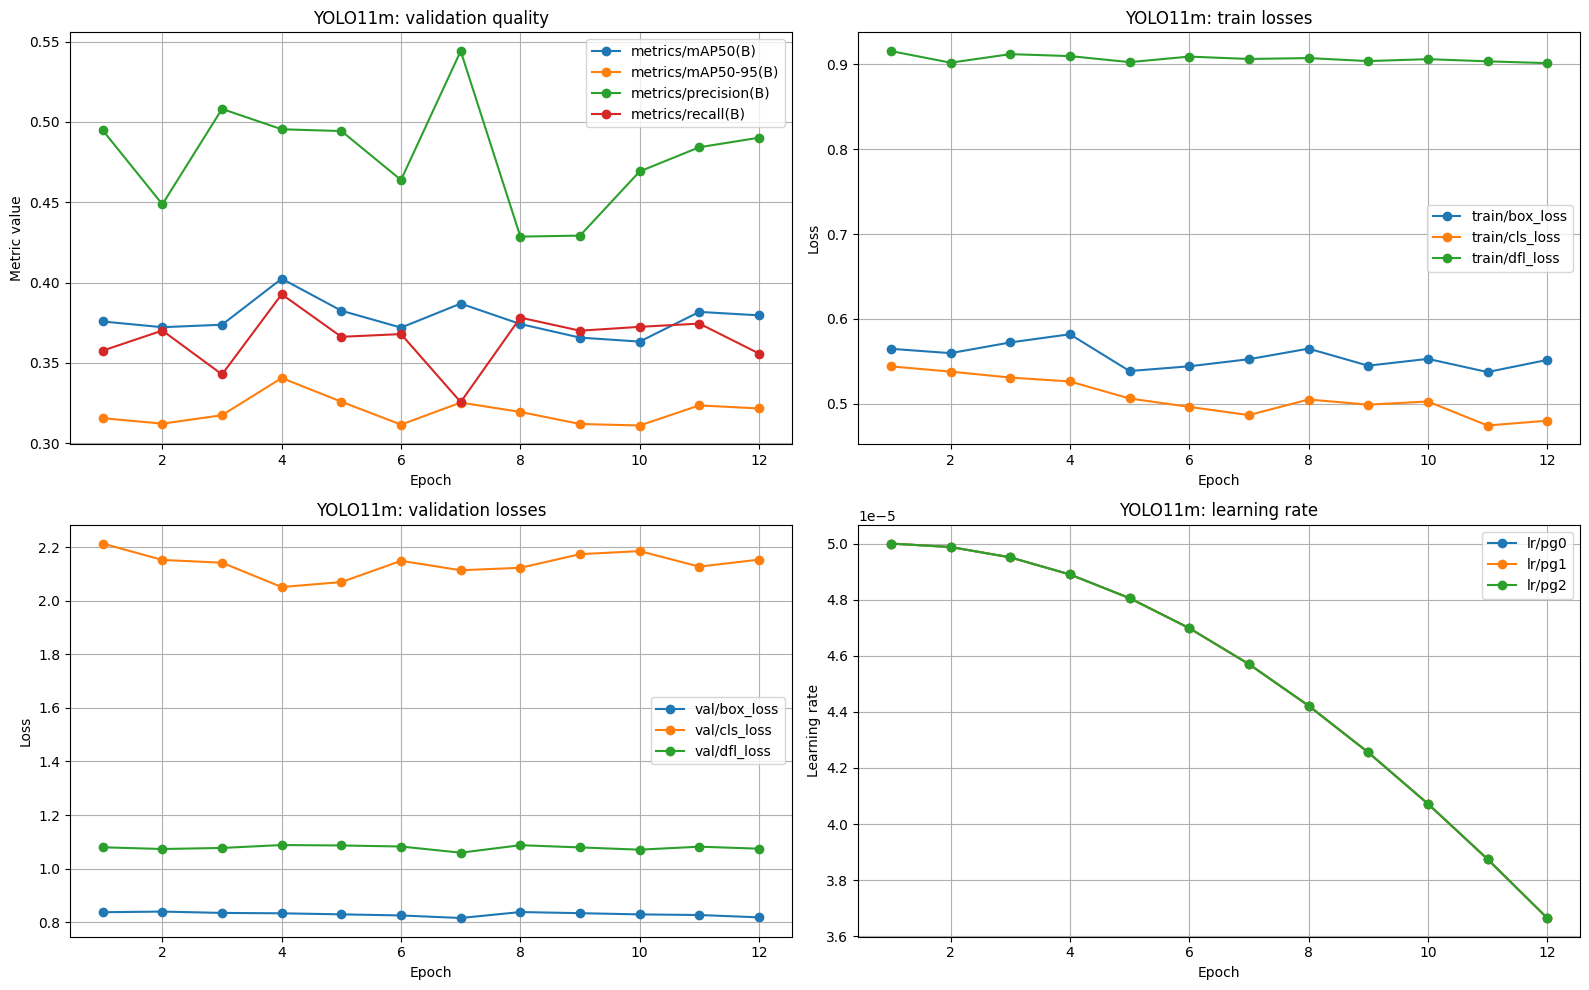

/content/drive/MyDrive/taco_yolo_runs/yolo11m_finetune_30/results.png


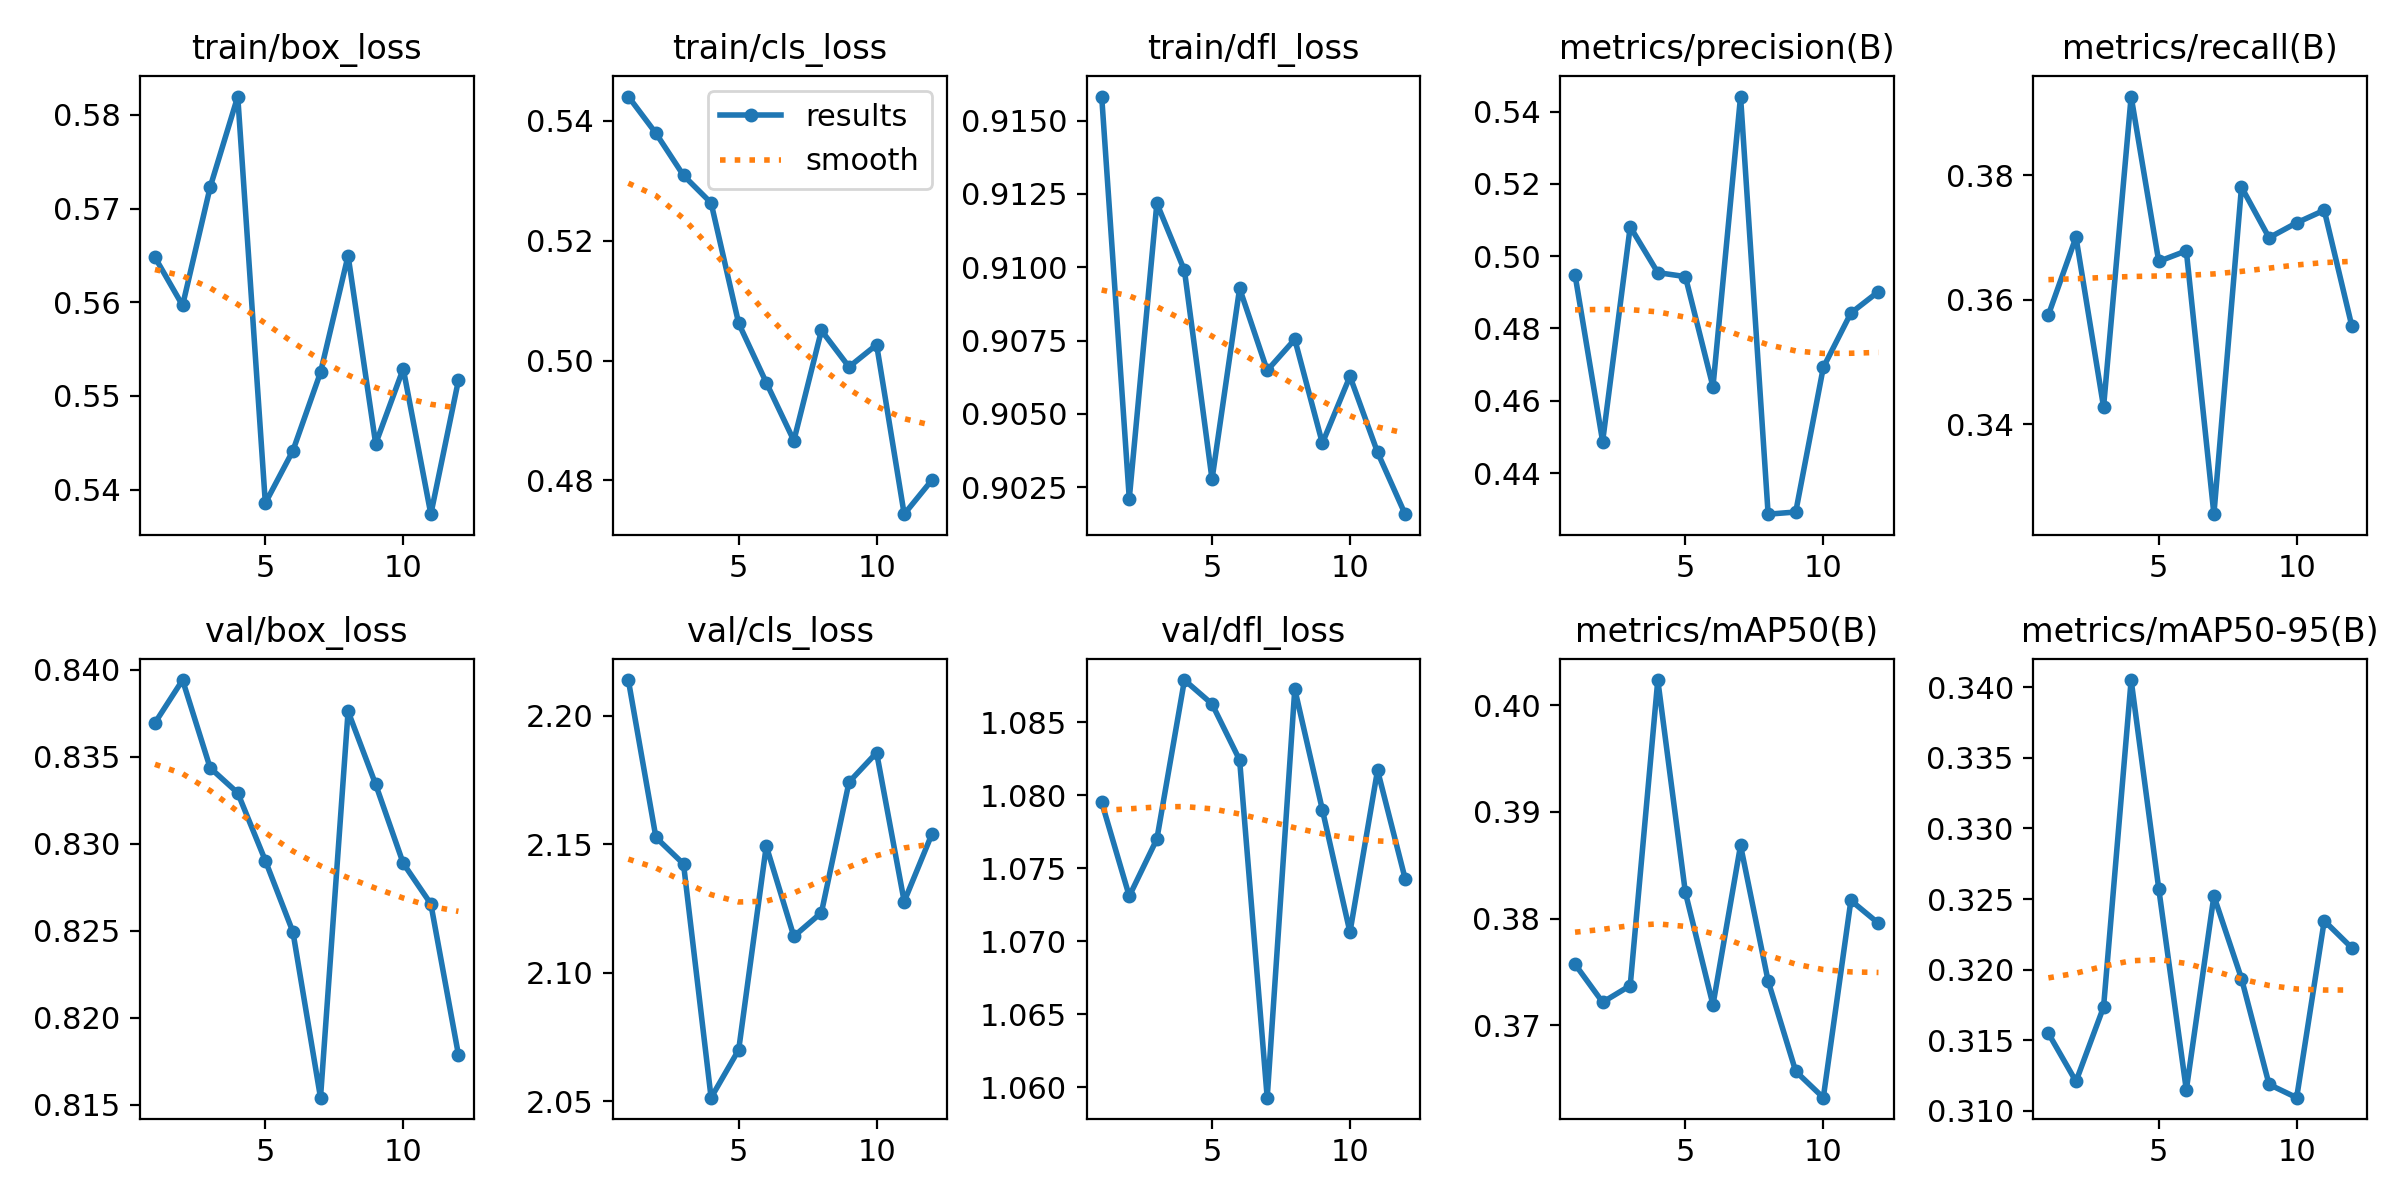

/content/drive/MyDrive/taco_yolo_runs/yolo11m_finetune_30/confusion_matrix.png


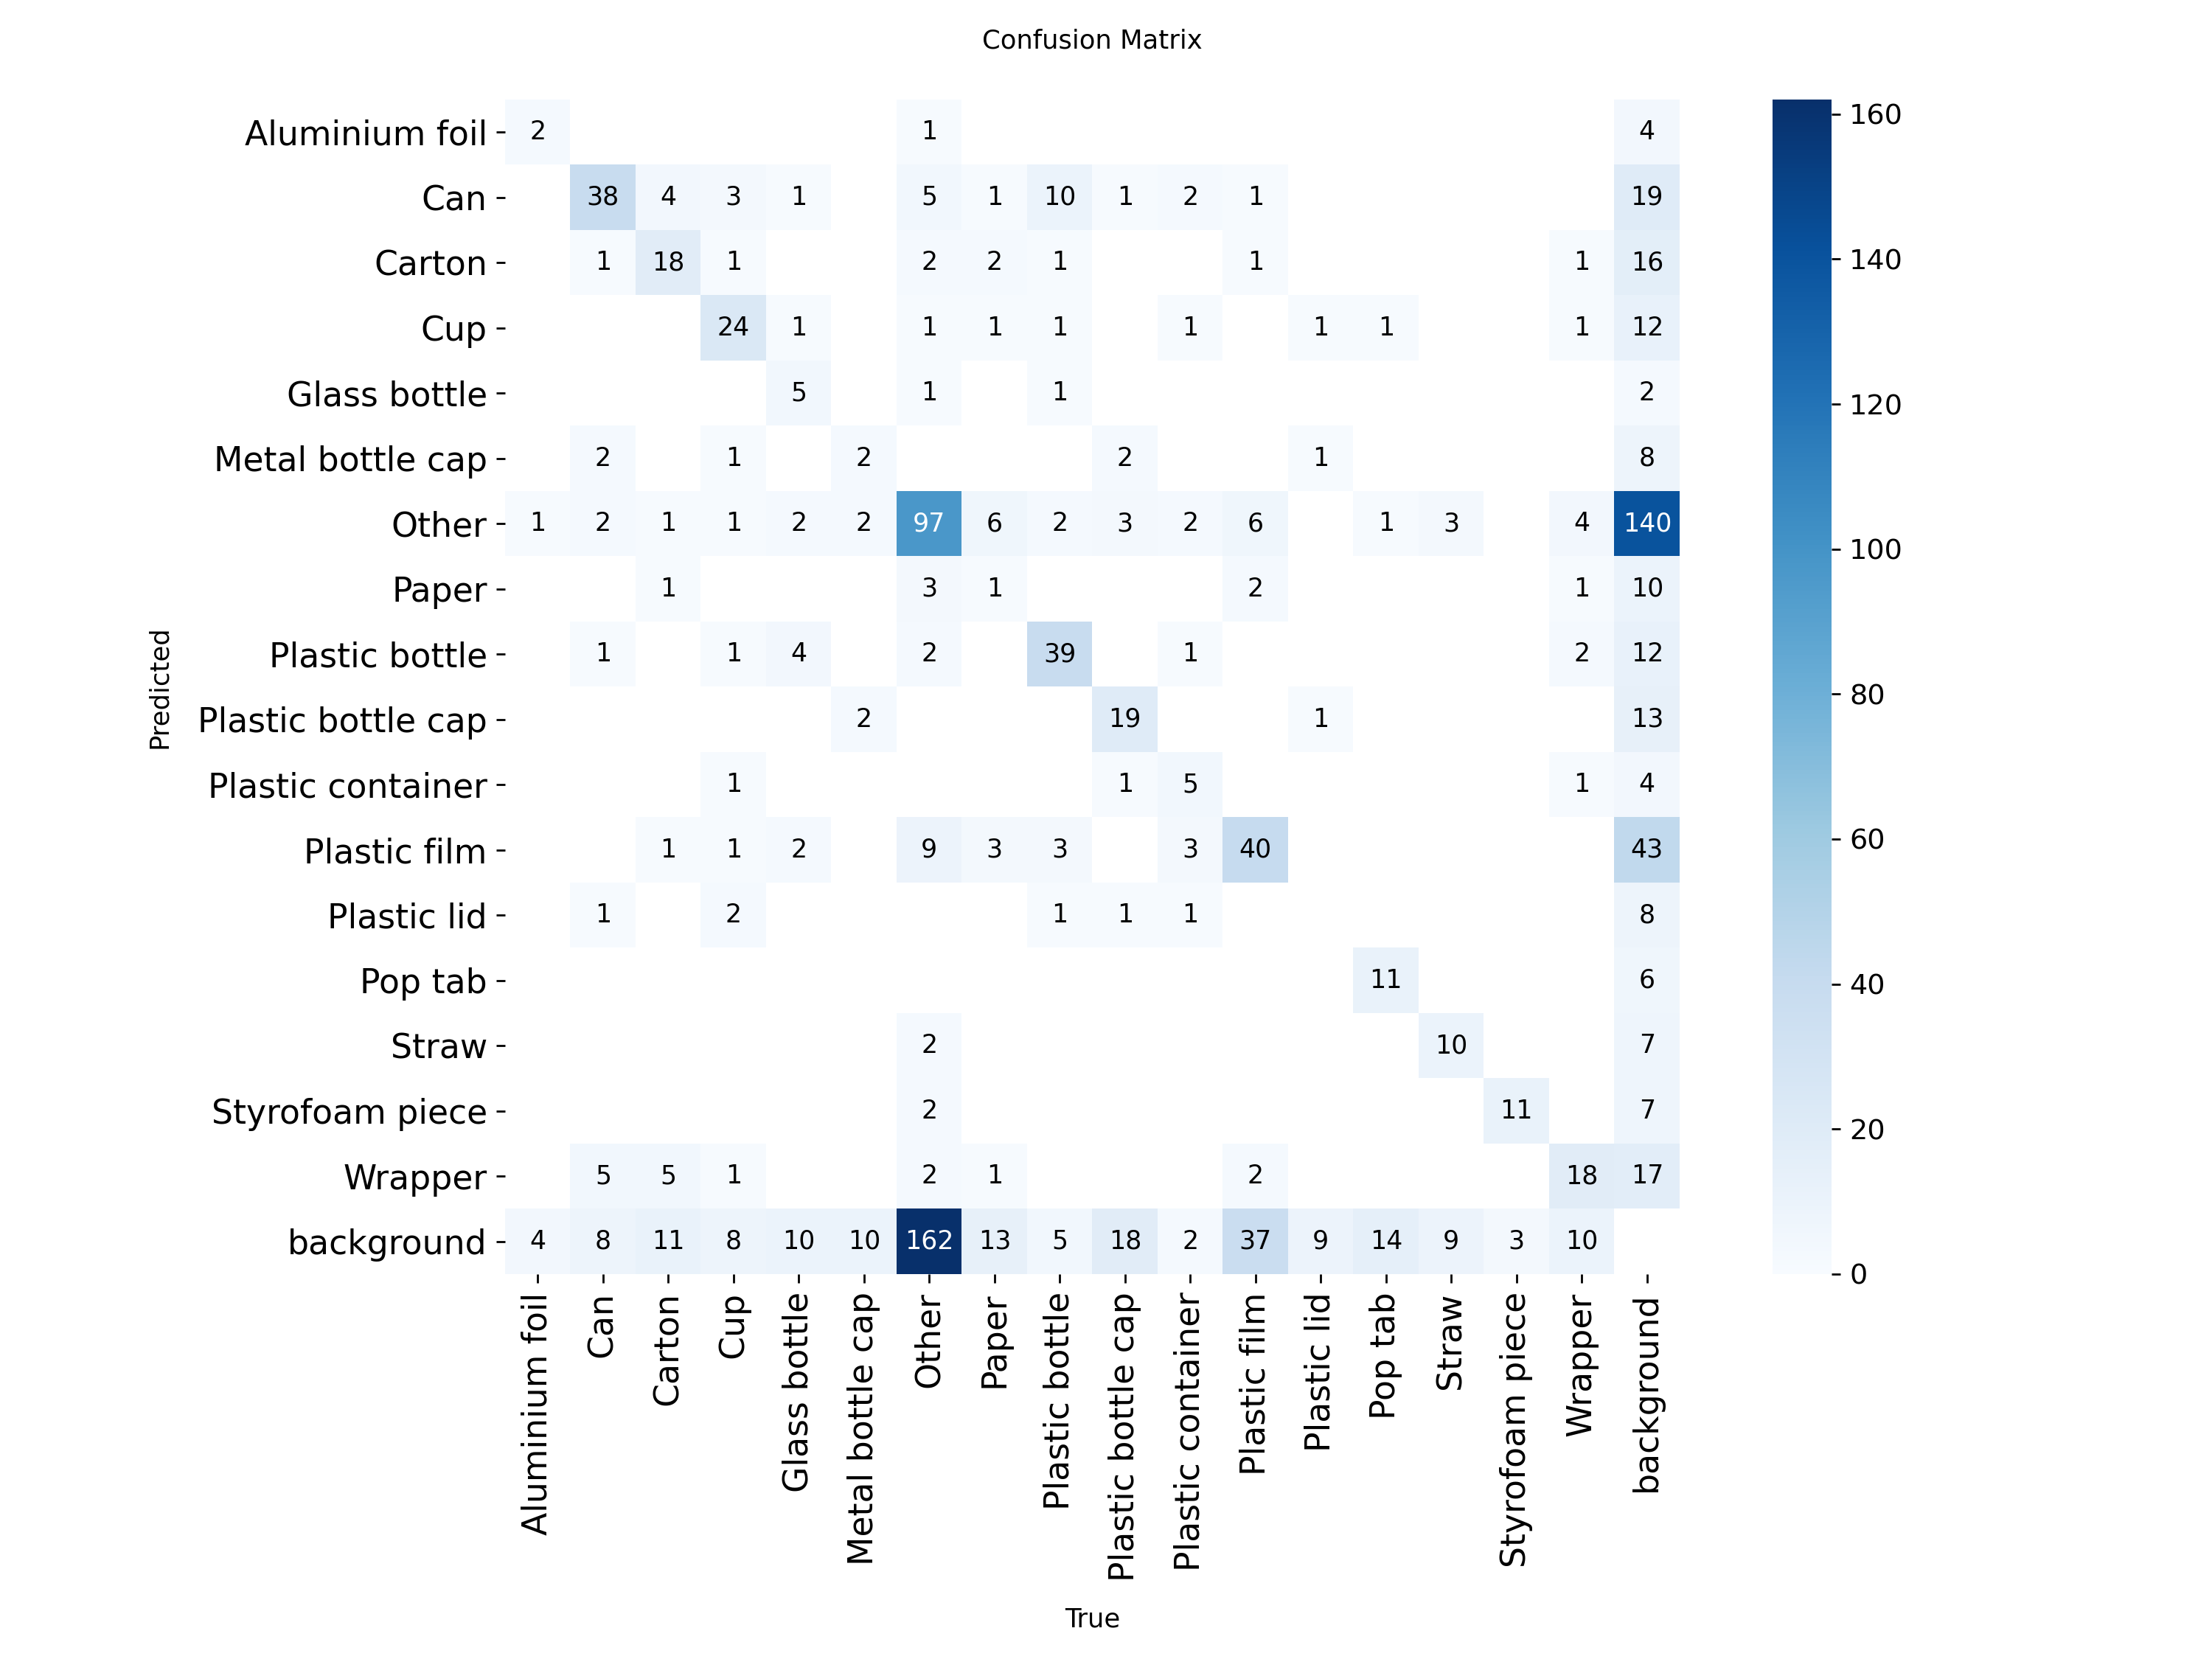

/content/drive/MyDrive/taco_yolo_runs/yolo11m_finetune_30/confusion_matrix_normalized.png


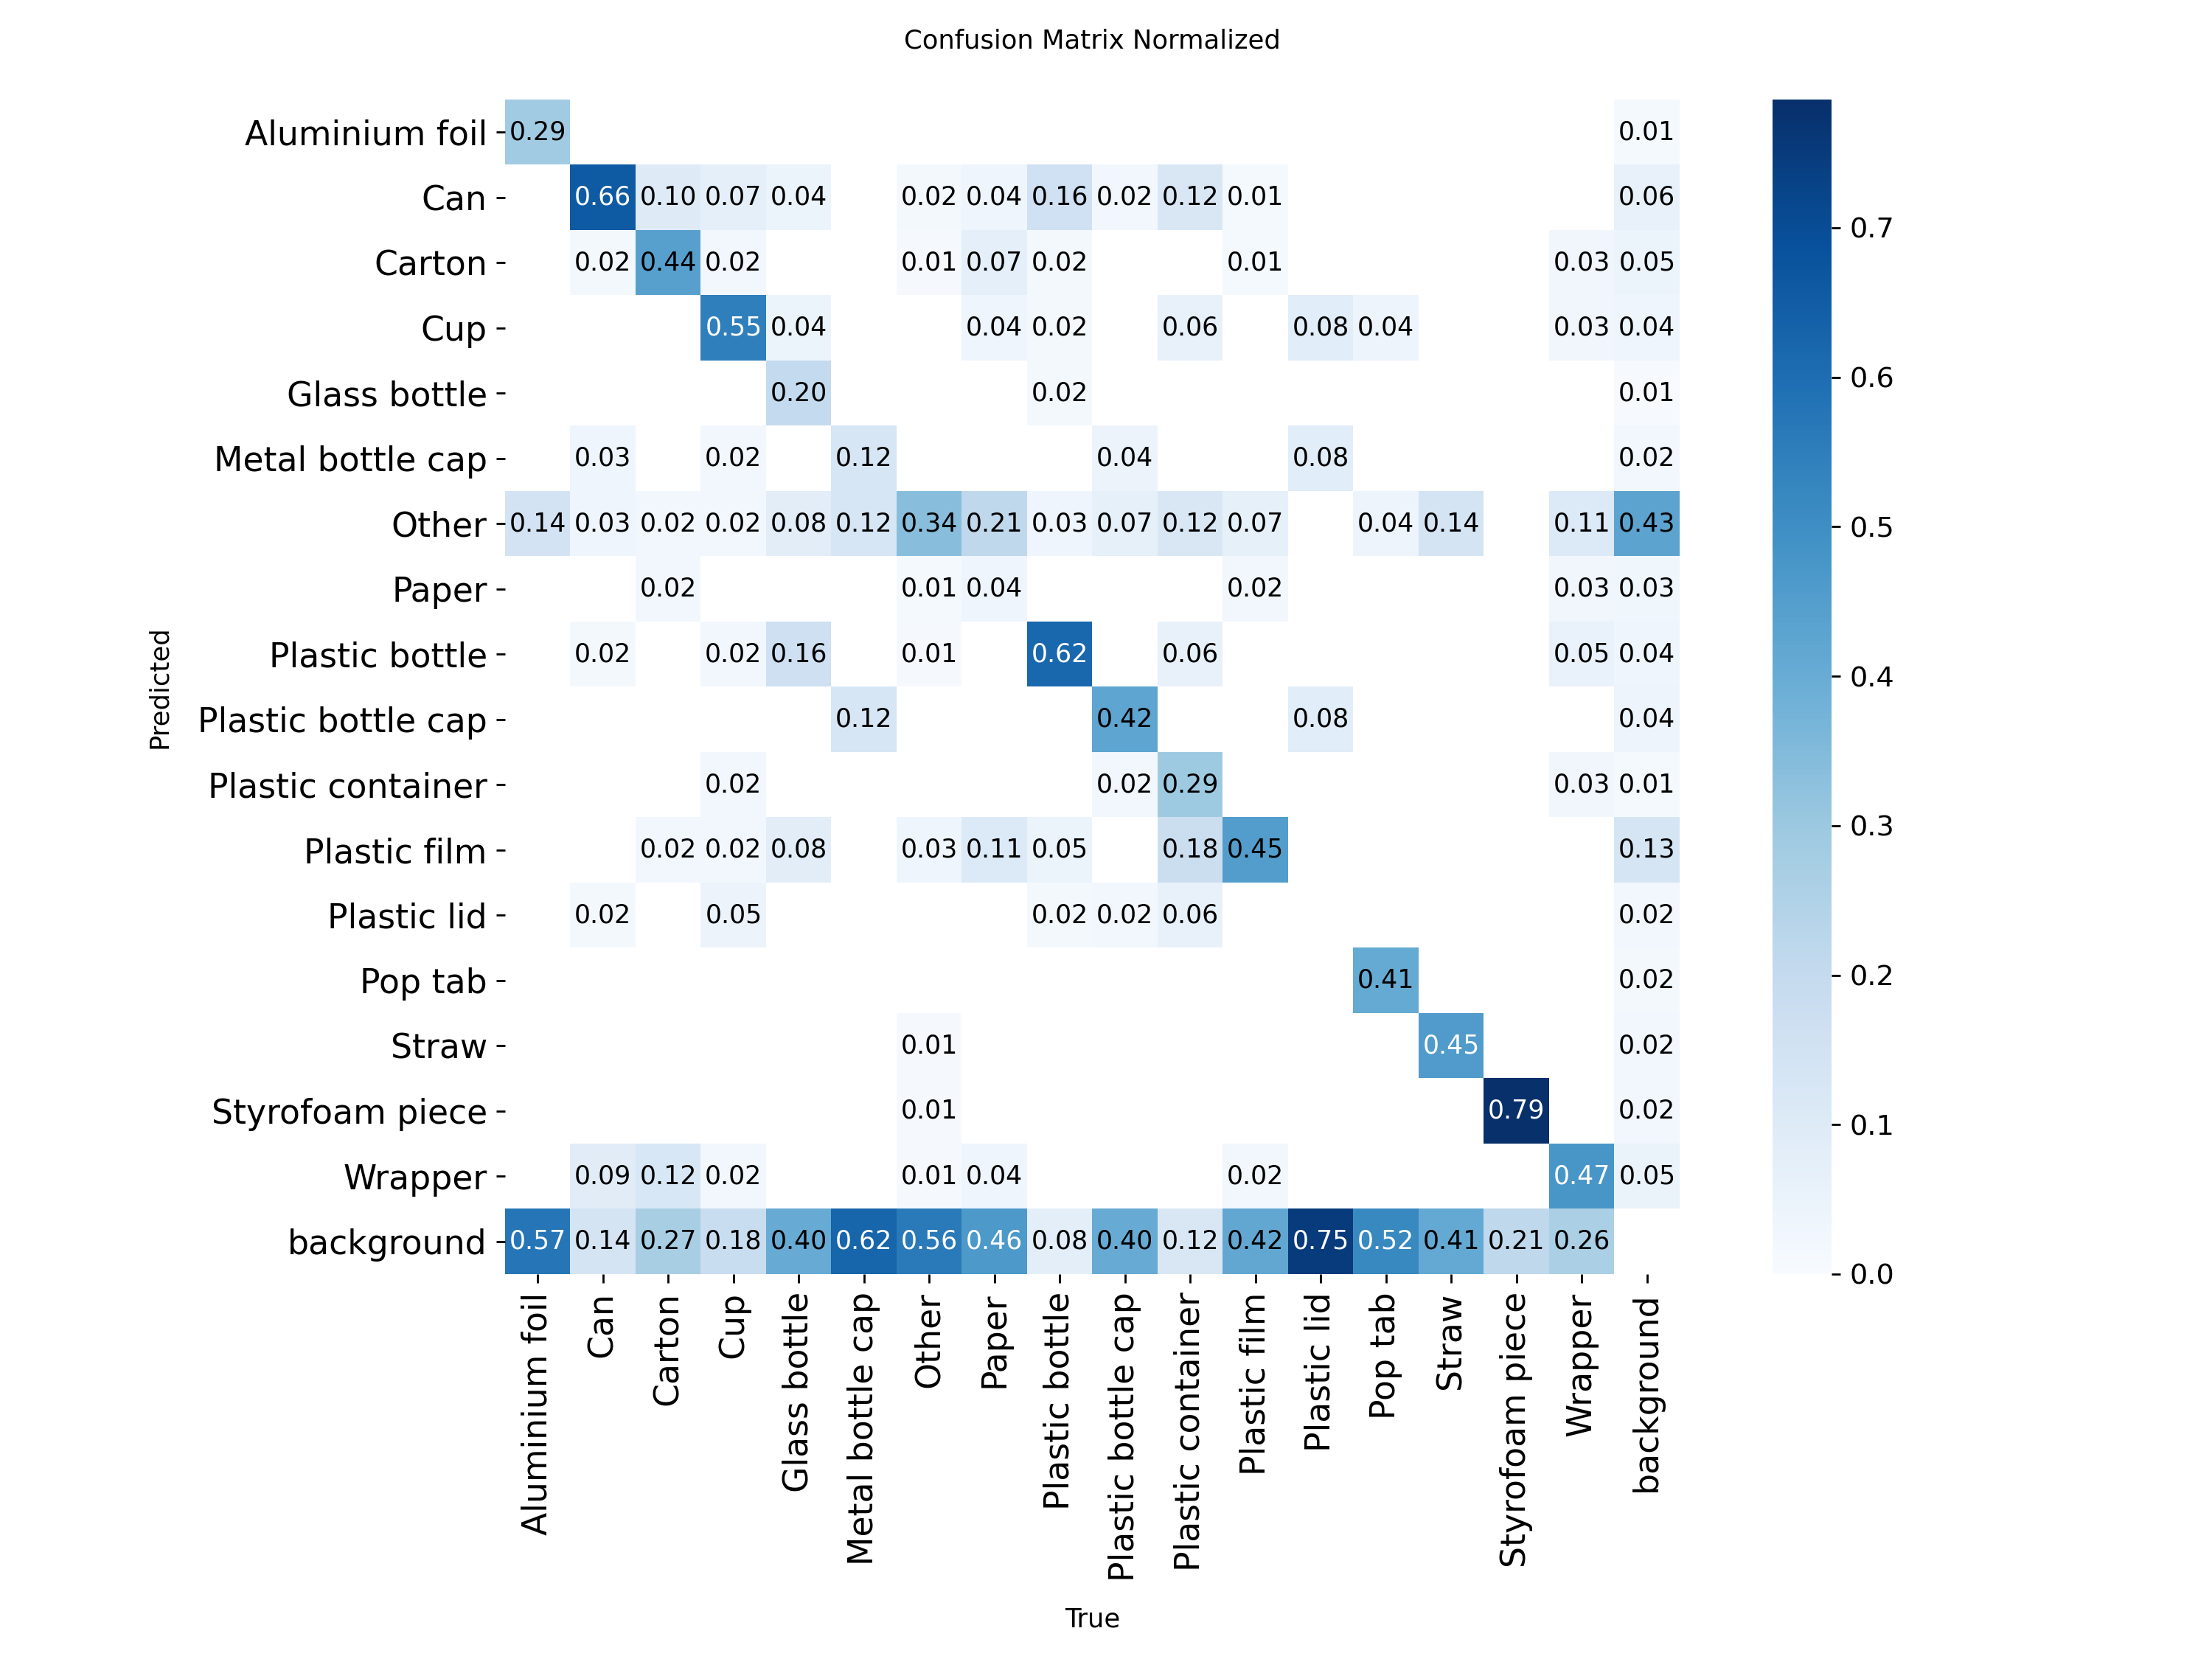

Missing artifact: /content/drive/MyDrive/taco_yolo_runs/yolo11m_finetune_30/PR_curve.png
Missing artifact: /content/drive/MyDrive/taco_yolo_runs/yolo11m_finetune_30/F1_curve.png
/content/drive/MyDrive/taco_yolo_runs/yolo11m_finetune_30/val_batch0_labels.jpg


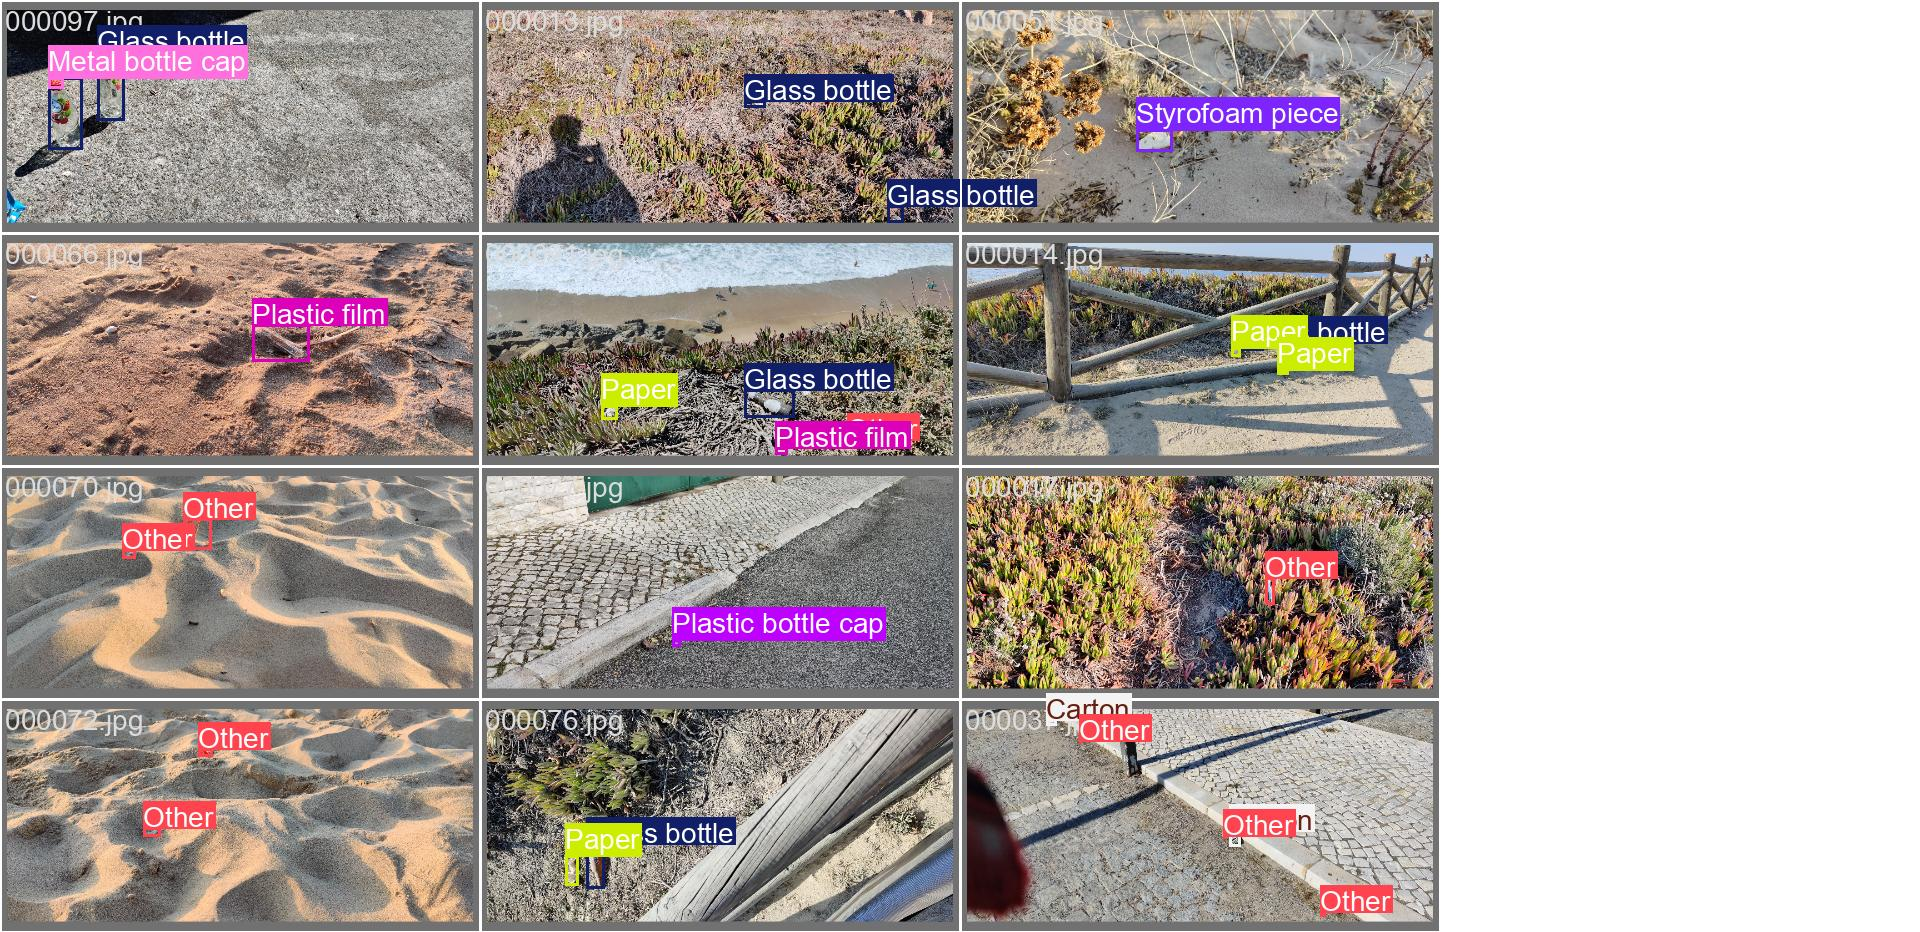

/content/drive/MyDrive/taco_yolo_runs/yolo11m_finetune_30/val_batch0_pred.jpg


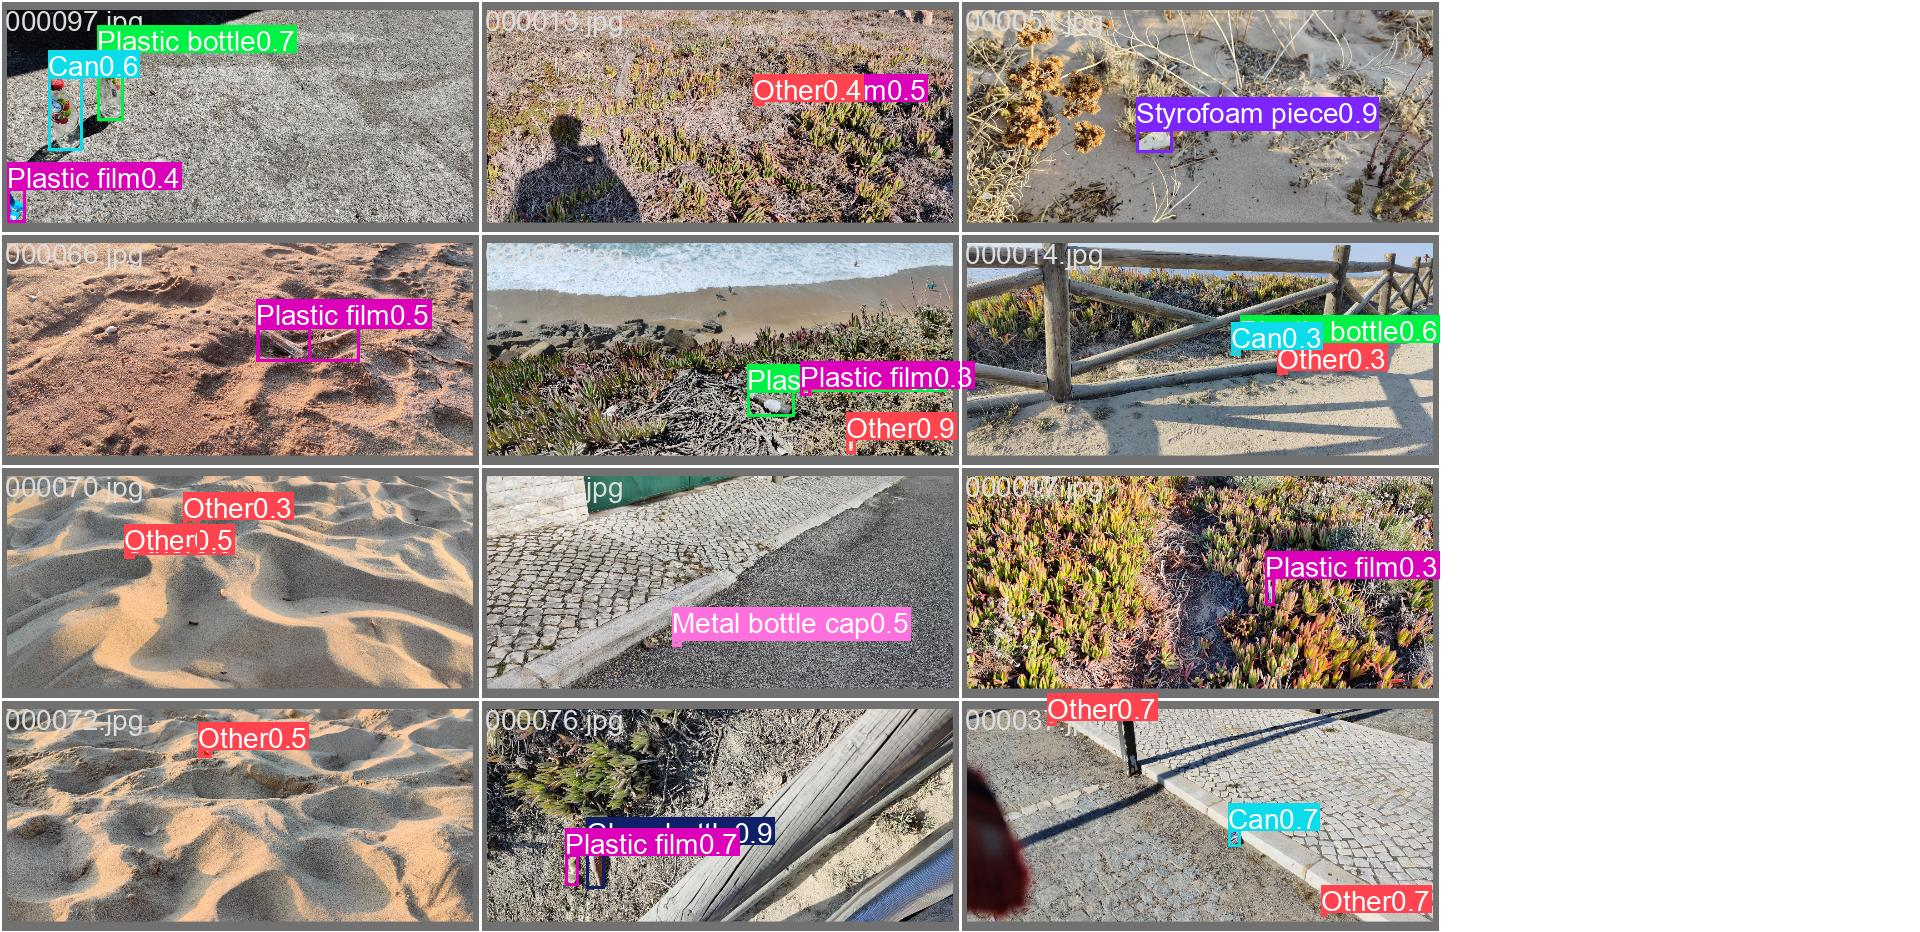

In [11]:
YOLO11M_RUN_DIR = Path("/content/drive/MyDrive/taco_yolo_runs/yolo11m_finetune_30")

if not YOLO11M_RUN_DIR.exists():
    YOLO11M_RUN_DIR = Path("/content/drive/MyDrive/taco_yolo_runs/yolo11m_60")

print(f"Visualizing run: {YOLO11M_RUN_DIR}")

yolo11m_results_df = load_yolo_results(YOLO11M_RUN_DIR)
print_best_yolo_metrics(yolo11m_results_df)
plot_yolo_training_curves(yolo11m_results_df, title="YOLO11m")
display_yolo_artifacts(YOLO11M_RUN_DIR)

### Observations

The YOLO11m experiment substantially improves over the earlier Mask R-CNN experiments and becomes a strong detection baseline for the 17-class setup. The final fine-tuned checkpoint reaches approximately `mAP@0.5 = 0.402` and `mAP@0.5:0.95 = 0.341`.

The fine-tuning stage improves the model only marginally compared with the preceding YOLO11m checkpoint. This suggests that the 17-class configuration is close to saturation for this model size and training setup. Further large gains are unlikely to come from simply extending YOLO11m training; changing model capacity or reducing class complexity is a better next experiment.

# YOLO v11l

The YOLO11l experiment tests whether a larger detector and a simpler label space can push the detection score beyond the project target. Instead of keeping all 17 classes, the dataset is reduced to the most useful top-5 categories. This isolates the effect of class granularity and reduces the amount of noisy fine-grained classification the model has to solve.

## 5 Classes

This block trains YOLO11l on a strongly reduced 5-class task. The purpose is to check the best-case scenario for the detector when class ambiguity is minimized. The selected labels correspond to the most frequent and visually meaningful trash groups from the earlier experiments.

In [6]:
YOLO_TOP5_DIR = Path("/content/taco_yolo_top5")

SELECTED_CLASSES = [
    "Can",
    "Plastic bottle",
    "Plastic bottle cap",
    "Cup",
    "Plastic film",
]

MAP_TOP5 = {
    class_name: class_name
    for class_name in SELECTED_CLASSES
}

### Convert TACO to YOLO Format

This conversion creates a separate YOLO dataset for the top-5 class experiment. Categories outside the selected list are dropped instead of being merged into a broad `Other` class. Images that no longer contain any selected object are skipped, so the model is trained on images with relevant labeled targets only.

In [2]:
import json
import os
from pathlib import Path
import shutil

import torch


def convert_taco_to_yolo(
    taco_dir,
    output_dir,
    category_mapping,
    train_fraction=0.8,
    seed=42,
    image_mode="copy",
    drop_other=False,
    drop_empty_images=False,
):
    """Convert COCO-style TACO annotations to YOLO detection format.

    Args:
        taco_dir (str | Path): Directory containing `annotations.json`
            and image folders such as `batch_1`, `batch_2`, etc.
        output_dir (str | Path): Destination directory for the YOLO dataset.
        category_mapping (dict[str, str]): Mapping from original TACO category
            names to the target/reduced class names.
        train_fraction (float): Fraction of images used for training.
        seed (int): Seed for deterministic image-level split.
        image_mode (str): How images are materialized. One of `copy`,
            `symlink`, or `hardlink`.
        drop_other (bool): If True, annotations mapped to `Other` are removed.
        drop_empty_images (bool): If True, images with no remaining annotations
            after filtering are skipped.

    Returns:
        Path: Path to generated `taco.yaml`.
    """
    taco_dir = Path(taco_dir)
    output_dir = Path(output_dir)

    with (taco_dir / "annotations.json").open() as file:
        coco = json.load(file)

    images = {
        int(image["id"]): image
        for image in coco["images"]
    }

    categories = {
        int(category["id"]): category["name"]
        for category in coco["categories"]
    }

    annotations_by_image = {}
    for annotation in coco["annotations"]:
        image_id = int(annotation["image_id"])
        annotations_by_image.setdefault(image_id, []).append(annotation)

    mapped_names = {
        category_mapping.get(name, "Other")
        for name in categories.values()
    }

    if drop_other:
        mapped_names.discard("Other")

    class_names = sorted(mapped_names)
    name_to_id = {
        name: class_id
        for class_id, name in enumerate(class_names)
    }

    category_id_to_yolo_id = {}

    for category_id, category_name in categories.items():
        mapped_name = category_mapping.get(category_name, "Other")

        if drop_other and mapped_name == "Other":
            category_id_to_yolo_id[category_id] = None
        else:
            category_id_to_yolo_id[category_id] = name_to_id.get(mapped_name)

    image_ids = sorted(images)

    generator = torch.Generator().manual_seed(seed)
    permutation = torch.randperm(
        len(image_ids),
        generator=generator,
    ).tolist()

    train_size = int(train_fraction * len(image_ids))

    train_ids = {
        image_ids[index]
        for index in permutation[:train_size]
    }

    val_ids = {
        image_ids[index]
        for index in permutation[train_size:]
    }

    def materialize_image(source, destination):
        destination.parent.mkdir(parents=True, exist_ok=True)

        if destination.exists() or destination.is_symlink():
            destination.unlink()

        if image_mode == "copy":
            shutil.copy2(source, destination)
        elif image_mode == "hardlink":
            os.link(source, destination)
        elif image_mode == "symlink":
            destination.symlink_to(source.resolve())
        else:
            raise ValueError(f"Unknown image_mode: {image_mode}")

    written_annotations = 0
    skipped_boxes = 0
    written_images = 0
    skipped_empty_images = 0

    for image_id, image in images.items():
        split = "train" if image_id in train_ids else "val"

        relative_path = Path(image["file_name"])
        source_path = taco_dir / relative_path

        image_path = output_dir / "images" / split / relative_path
        label_path = (
            output_dir
            / "labels"
            / split
            / relative_path.with_suffix(".txt")
        )

        image_width = int(image["width"])
        image_height = int(image["height"])

        label_lines = []

        for annotation in annotations_by_image.get(image_id, []):
            class_id = category_id_to_yolo_id[
                int(annotation["category_id"])
            ]

            if class_id is None:
                continue

            x, y, width, height = map(float, annotation["bbox"])

            x1 = min(max(x, 0.0), image_width)
            y1 = min(max(y, 0.0), image_height)
            x2 = min(max(x + width, 0.0), image_width)
            y2 = min(max(y + height, 0.0), image_height)

            width = x2 - x1
            height = y2 - y1

            if width <= 0 or height <= 0:
                skipped_boxes += 1
                continue

            x_center = ((x1 + x2) / 2) / image_width
            y_center = ((y1 + y2) / 2) / image_height
            width_normalized = width / image_width
            height_normalized = height / image_height

            label_lines.append(
                f"{class_id} "
                f"{x_center:.8f} "
                f"{y_center:.8f} "
                f"{width_normalized:.8f} "
                f"{height_normalized:.8f}"
            )

            written_annotations += 1

        if drop_empty_images and len(label_lines) == 0:
            skipped_empty_images += 1
            continue

        materialize_image(source_path, image_path)

        label_path.parent.mkdir(parents=True, exist_ok=True)
        label_path.write_text(
            "\n".join(label_lines) + ("\n" if label_lines else "")
        )

        written_images += 1

    output_dir.mkdir(parents=True, exist_ok=True)

    yaml_lines = [
        f'path: "{output_dir.resolve()}"',
        "train: images/train",
        "val: images/val",
        "names:",
    ]

    for class_id, class_name in enumerate(class_names):
        yaml_lines.append(
            f"  {class_id}: {json.dumps(class_name)}"
        )

    yaml_path = output_dir / "taco.yaml"
    yaml_path.write_text("\n".join(yaml_lines) + "\n")

    manifest = {
        "seed": seed,
        "train_fraction": train_fraction,
        "train_image_ids": sorted(train_ids),
        "val_image_ids": sorted(val_ids),
        "classes": class_names,
        "written_images": written_images,
        "written_annotations": written_annotations,
        "skipped_boxes": skipped_boxes,
        "skipped_empty_images": skipped_empty_images,
        "drop_other": drop_other,
        "drop_empty_images": drop_empty_images,
    }

    (output_dir / "split.json").write_text(
        json.dumps(manifest, indent=2)
    )

    print(f"Classes: {class_names}")
    print(f"Train images before filtering: {len(train_ids)}")
    print(f"Val images before filtering: {len(val_ids)}")
    print(f"Written images: {written_images}")
    print(f"Written annotations: {written_annotations}")
    print(f"Skipped invalid boxes: {skipped_boxes}")
    print(f"Skipped empty images: {skipped_empty_images}")
    print(f"YAML: {yaml_path}")

    return yaml_path

In [31]:
from pathlib import Path

YOLO_TOP5_DIR = Path("/content/taco_yolo_top5")

SELECTED_CLASSES = [
    "Can",
    "Plastic bottle",
    "Plastic bottle cap",
    "Cup",
    "Plastic film",
]

MAP_TOP5 = {
    class_name: class_name
    for class_name in SELECTED_CLASSES
}

yaml_path_top5 = convert_taco_to_yolo(
    taco_dir=TACO_DIR,
    output_dir=YOLO_TOP5_DIR,
    category_mapping=MAP_TOP5,
    train_fraction=0.8,
    seed=42,
    image_mode="copy",
    drop_other=True,
    drop_empty_images=True,
)

print(Path(yaml_path_top5).read_text())

Classes: ['Plastic bottle cap', 'Plastic film']
Train images before filtering: 1200
Val images before filtering: 300
Written images: 474
Written annotations: 660
Skipped invalid boxes: 0
Skipped empty images: 1026
YAML: /content/taco_yolo_top5/taco.yaml
path: "/content/taco_yolo_top5"
train: images/train
val: images/val
names:
  0: "Plastic bottle cap"
  1: "Plastic film"



In [32]:
from pathlib import Path

YOLO_TOP10_DIR = Path("/content/taco_yolo_top10")

SELECTED_CLASSES = [
    "Can",
    "Plastic bottle",
    "Plastic bottle cap",
    "Cup",
    "Plastic film",
    "Carton",
    "Wrapper",
    "Paper",
    "Glass bottle",
    "Pop tab",
]

MAP_TOP10 = {
    class_name: class_name
    for class_name in SELECTED_CLASSES
}

yaml_path_top10 = convert_taco_to_yolo(
    taco_dir=TACO_DIR,
    output_dir=YOLO_TOP10_DIR,
    category_mapping=MAP_TOP10,
    train_fraction=0.8,
    seed=42,
    image_mode="copy",
    drop_other=True,
    drop_empty_images=True,
)

print(Path(yaml_path_top10).read_text())

Classes: ['Glass bottle', 'Plastic bottle cap', 'Plastic film', 'Pop tab']
Train images before filtering: 1200
Val images before filtering: 300
Written images: 591
Written annotations: 863
Skipped invalid boxes: 0
Skipped empty images: 909
YAML: /content/taco_yolo_top10/taco.yaml
path: "/content/taco_yolo_top10"
train: images/train
val: images/val
names:
  0: "Glass bottle"
  1: "Plastic bottle cap"
  2: "Plastic film"
  3: "Pop tab"



### Train

The training stage contains a short smoke test and then a full run. The smoke test verifies that the converted top-5 dataset is valid, while the full run searches for the best checkpoint with the larger YOLO11l model.

#### Smoke Test

The YOLO11l smoke test validates the top-5 dataset conversion and confirms that the larger model can train with the selected image size and batch size. As with the YOLO11m smoke test, the goal is pipeline validation rather than final performance.

In [33]:
from ultralytics import YOLO

smoke_model = YOLO("yolo11l.pt")

smoke_results = smoke_model.train(
    data=str(yaml_path_top5),
    epochs=3,
    imgsz=1024,
    batch=4,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/yolo_runs",
    name="yolo11l_top5_smoke",
    plots=True,
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/taco_yolo_top5/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11l_top5_smoke, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

#### Full Model

The full YOLO11l run trains the larger model on the reduced top-5 dataset. The image size is increased to improve small-object detection, while the reduced taxonomy makes the classification task easier. This experiment is intended to test whether `mAP@0.5 >= 0.5` is achievable when class confusion is reduced.

In [34]:
from ultralytics import YOLO

model = YOLO("/content/yolo_runs/yolo11l_top5_smoke/weights/best.pt")

results = model.train(
    data=str(yaml_path_top5),
    epochs=80,
    imgsz=1280,
    batch=4,
    patience=15,
    optimizer="AdamW",
    lr0=5e-4,
    lrf=0.05,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/drive/MyDrive/taco_yolo_runs",
    name="yolo11l_top5_1280",
    save_period=1,
    exist_ok=True,
    save=True,
    plots=True,
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/taco_yolo_top5/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo_runs/yolo11l_top5_smoke/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11l_top5_1280, nbs=64, nms=False, op

#### Evaluate Results

The best YOLO11l checkpoint is evaluated using the same validation settings as training. The reported values are the main comparison point for the top-5 experiment and should be compared separately from the 17-class YOLO11m run, because the task definition is different.

In [35]:
from pathlib import Path
from ultralytics import YOLO

run_dir = Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280")

best_model = YOLO(str(run_dir / "weights" / "best.pt"))

metrics = best_model.val(
    data=str(yaml_path_top5),
    imgsz=1280,
    batch=4,
    conf=0.001,
    iou=0.7,
    max_det=300,
    device=0,
    plots=True,
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,280,854 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3514.7±785.5 MB/s, size: 1588.6 KB)
val: Scanning /content/taco_yolo_top5/labels/val/batch_1.cache... 89 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 89/89 33.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 8.2it/s 2.8s<0.1s
                   all         89        114      0.592      0.497      0.502       0.35
    Plastic bottle cap         39         45      0.849      0.689      0.713      0.502
          Plastic film         50         69      0.334      0.304       0.29      0.198
Speed: 3.3ms preprocess, 16.8ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val-4
Precision: 0.5916087333471802
Recall: 0.4966183574879227
mAP@0.5:

#### Visualize

The visualization reads the saved Ultralytics run directory, plots metric/loss curves from `results.csv`, and displays generated validation artifacts such as confusion matrices, PR curves, and predicted validation batches.

Visualizing run: /content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280
Best epochs by mAP@0.5


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
32,33,0.59609,0.50325,0.50189,0.34816
38,39,0.54903,0.56232,0.50029,0.33525
47,48,0.62301,0.52560,0.49963,0.33573
33,34,0.55924,0.48495,0.49193,0.32506
45,46,0.51544,0.54010,0.48675,0.33385


Best epochs by mAP@0.5:0.95


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
32,33,0.59609,0.50325,0.50189,0.34816
47,48,0.62301,0.52560,0.49963,0.33573
38,39,0.54903,0.56232,0.50029,0.33525
46,47,0.53977,0.57633,0.47493,0.33441
45,46,0.51544,0.54010,0.48675,0.33385


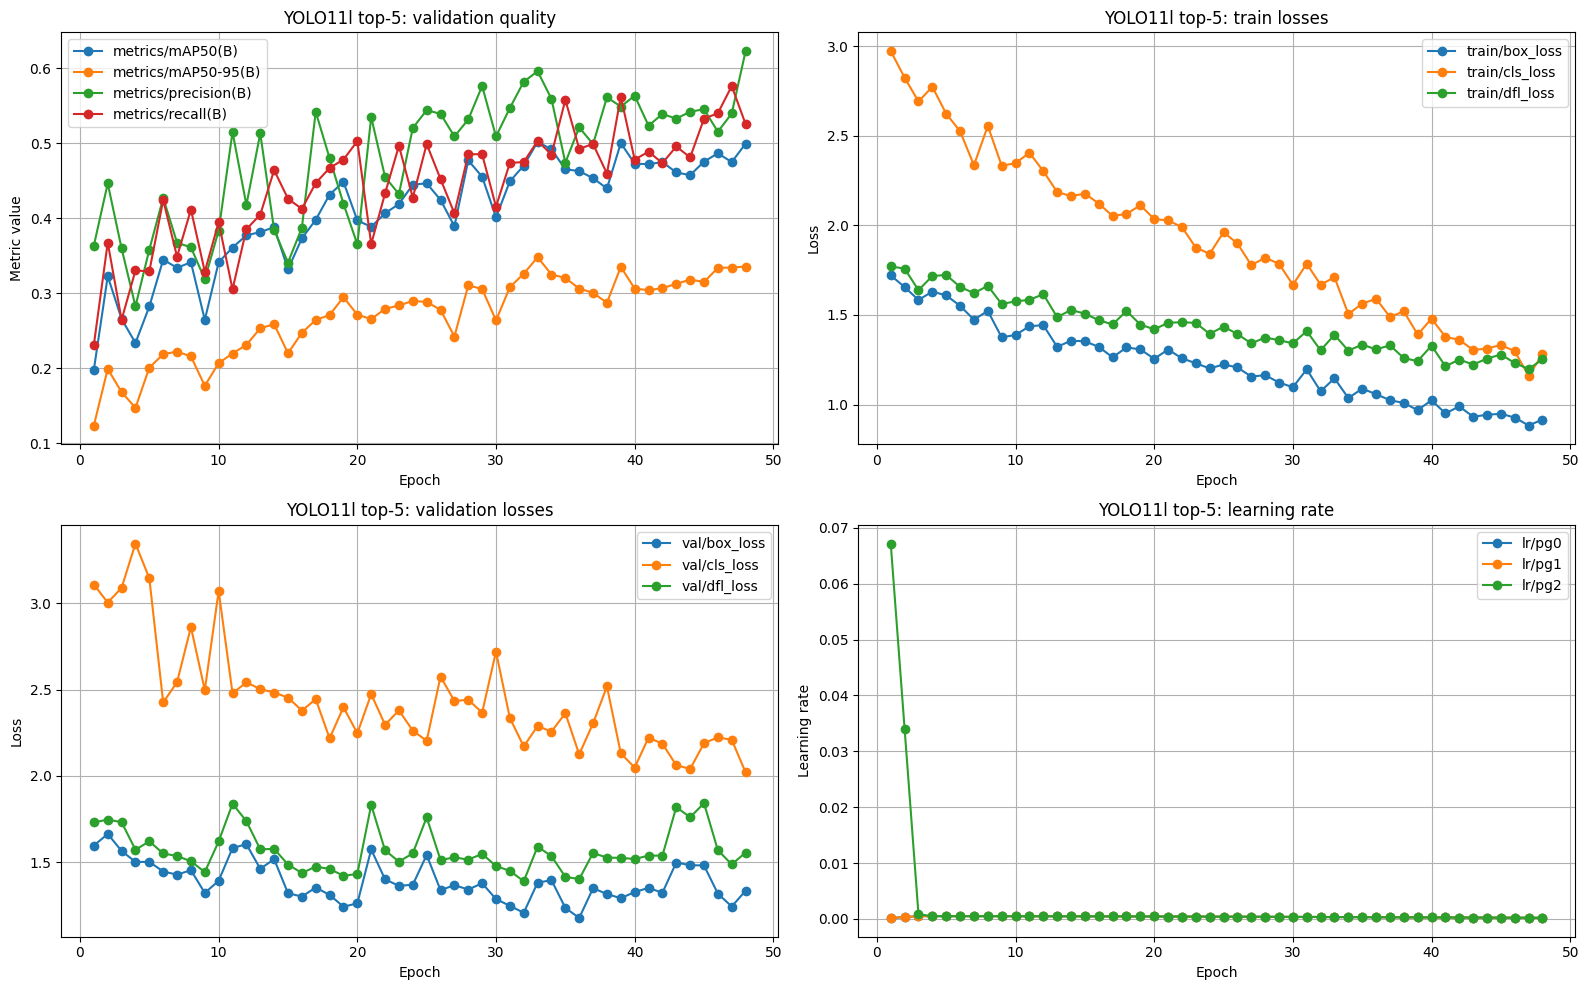

/content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280/results.png


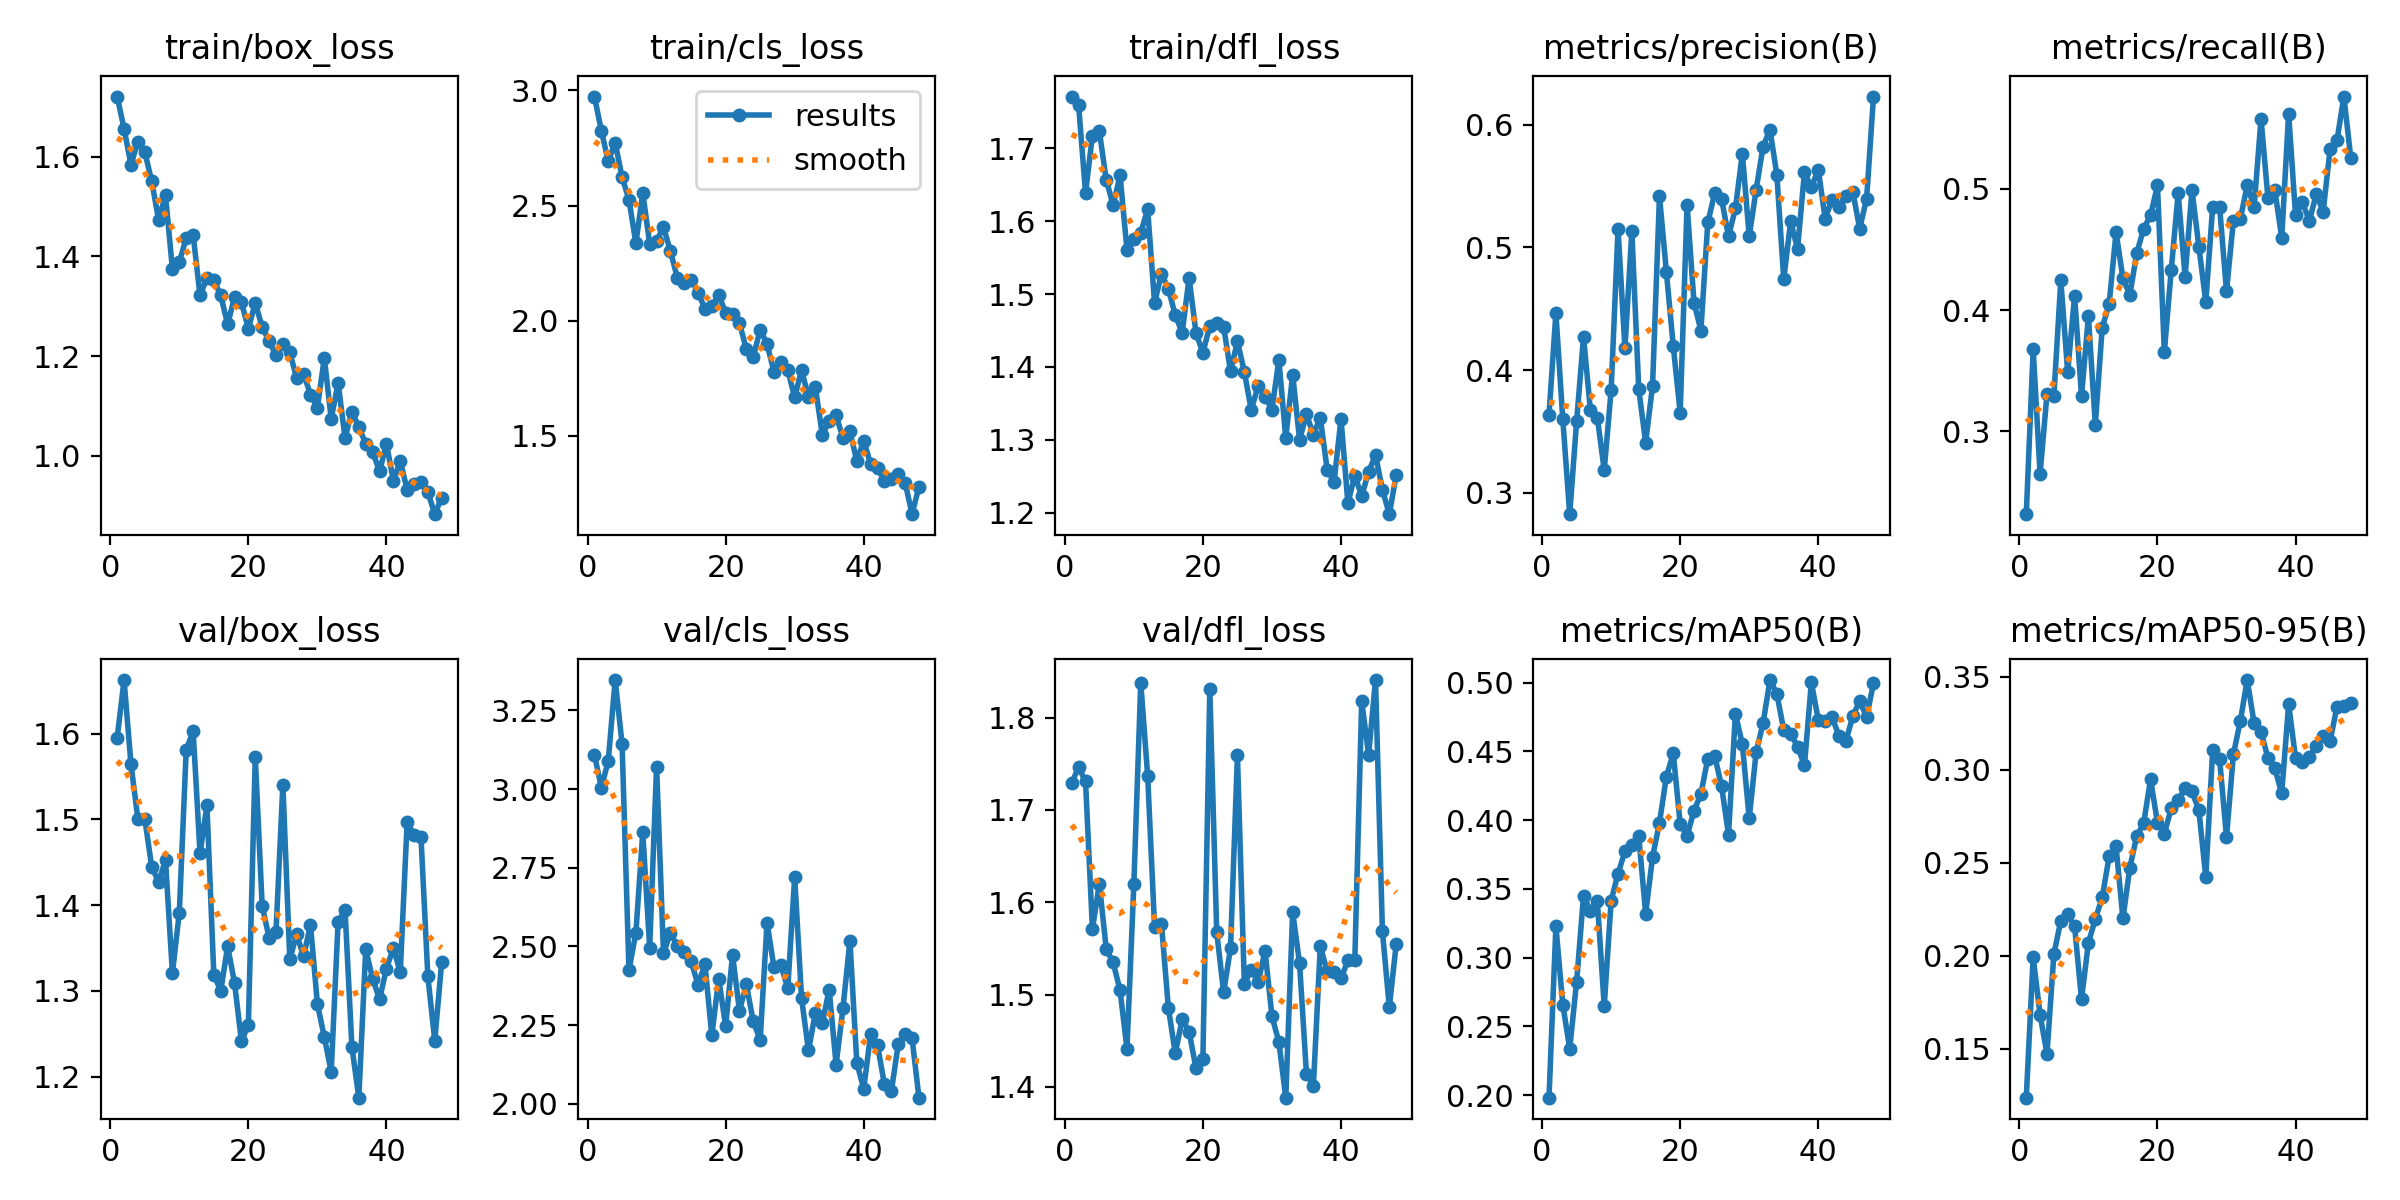

/content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280/confusion_matrix.png


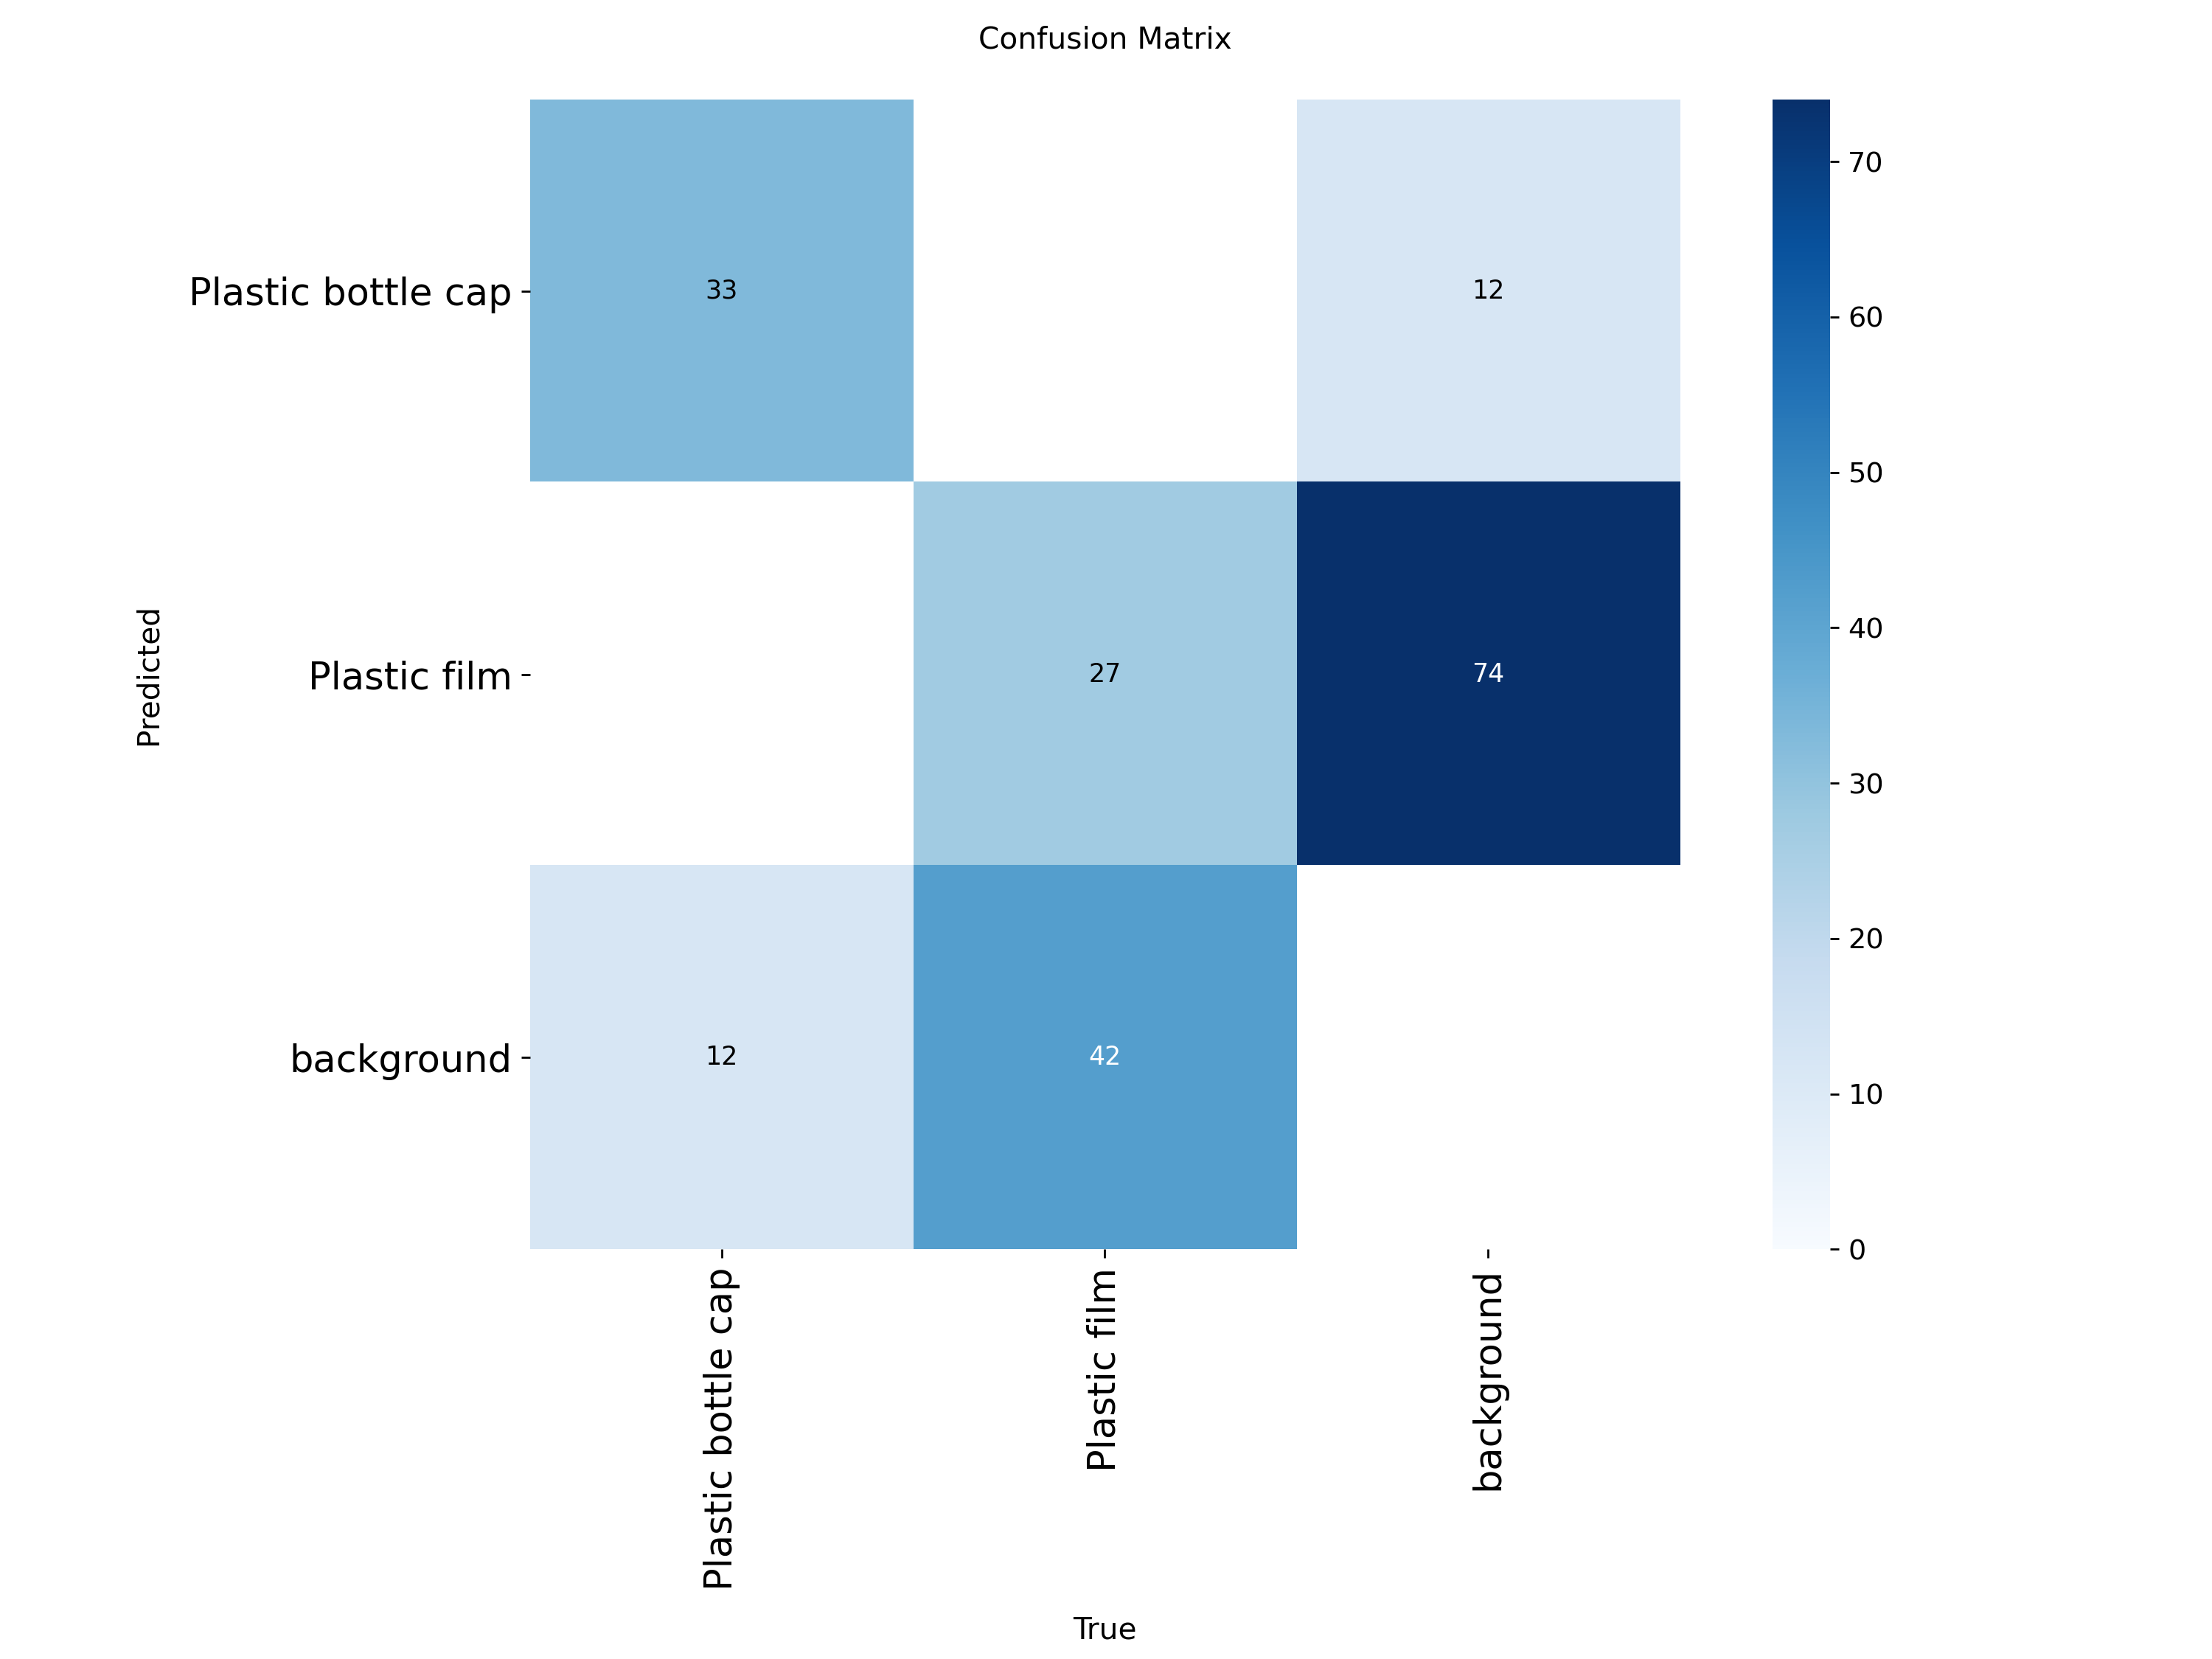

/content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280/confusion_matrix_normalized.png


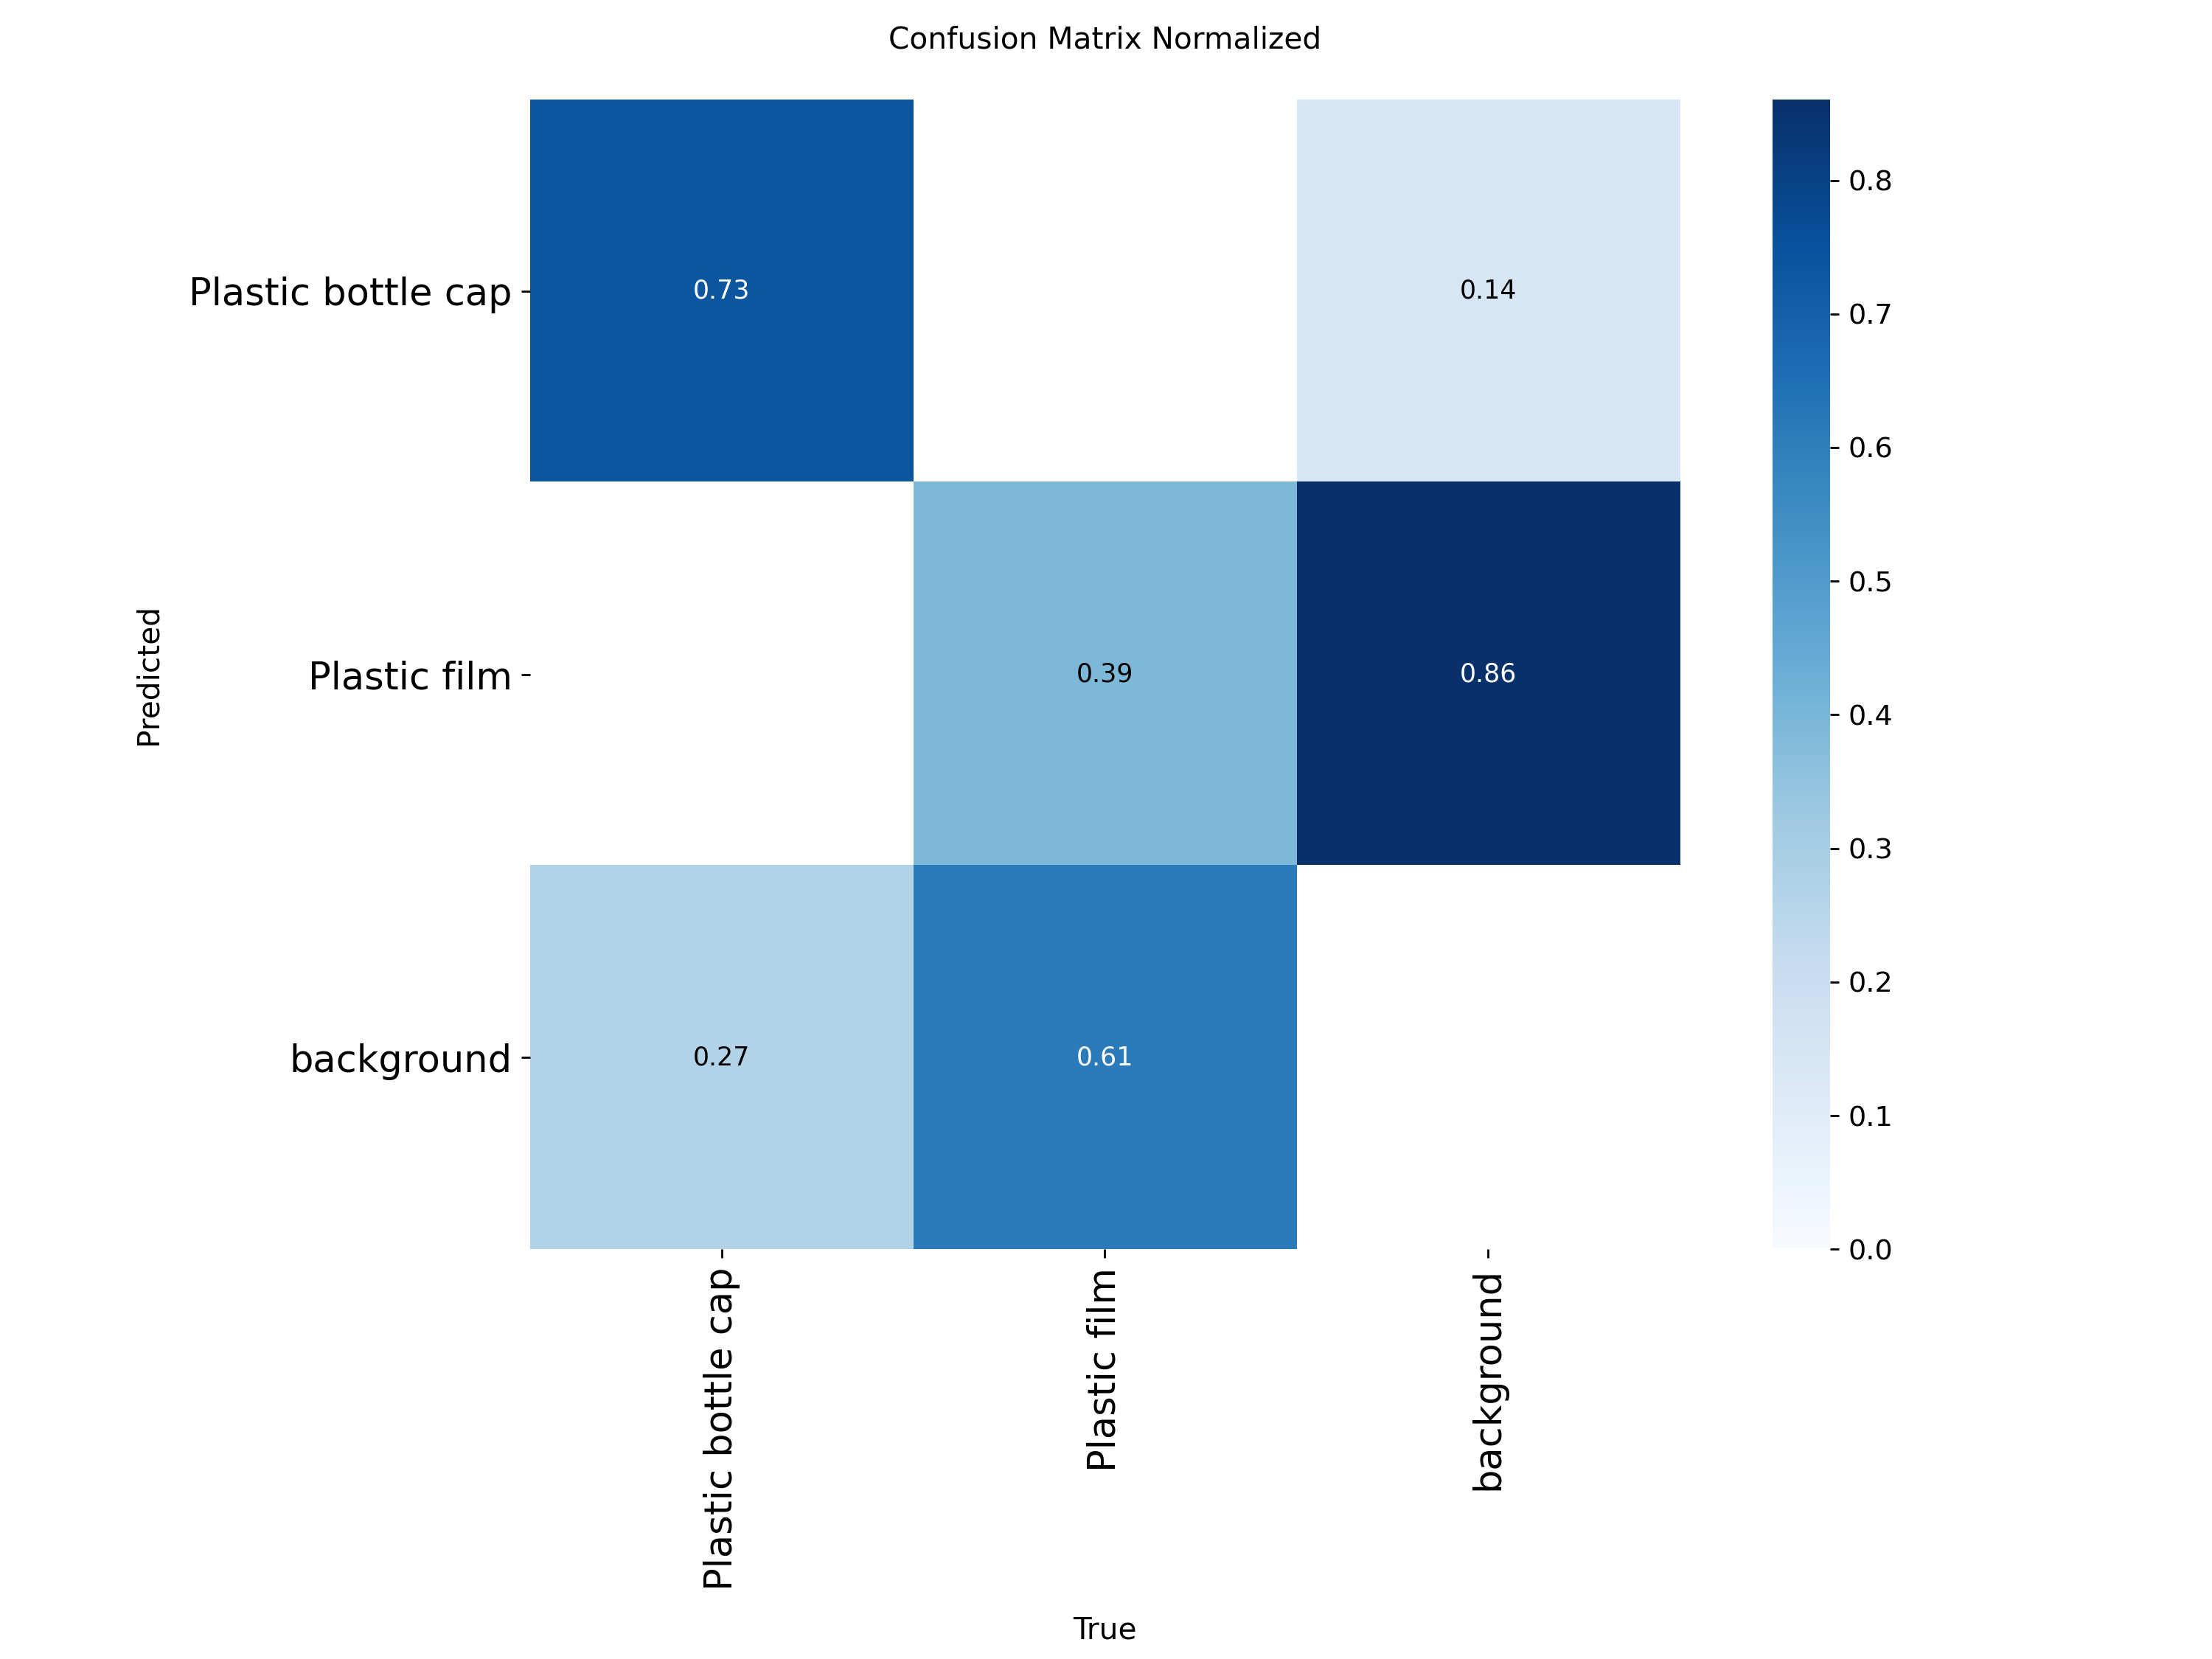

Missing artifact: /content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280/PR_curve.png
Missing artifact: /content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280/F1_curve.png
/content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280/val_batch0_labels.jpg


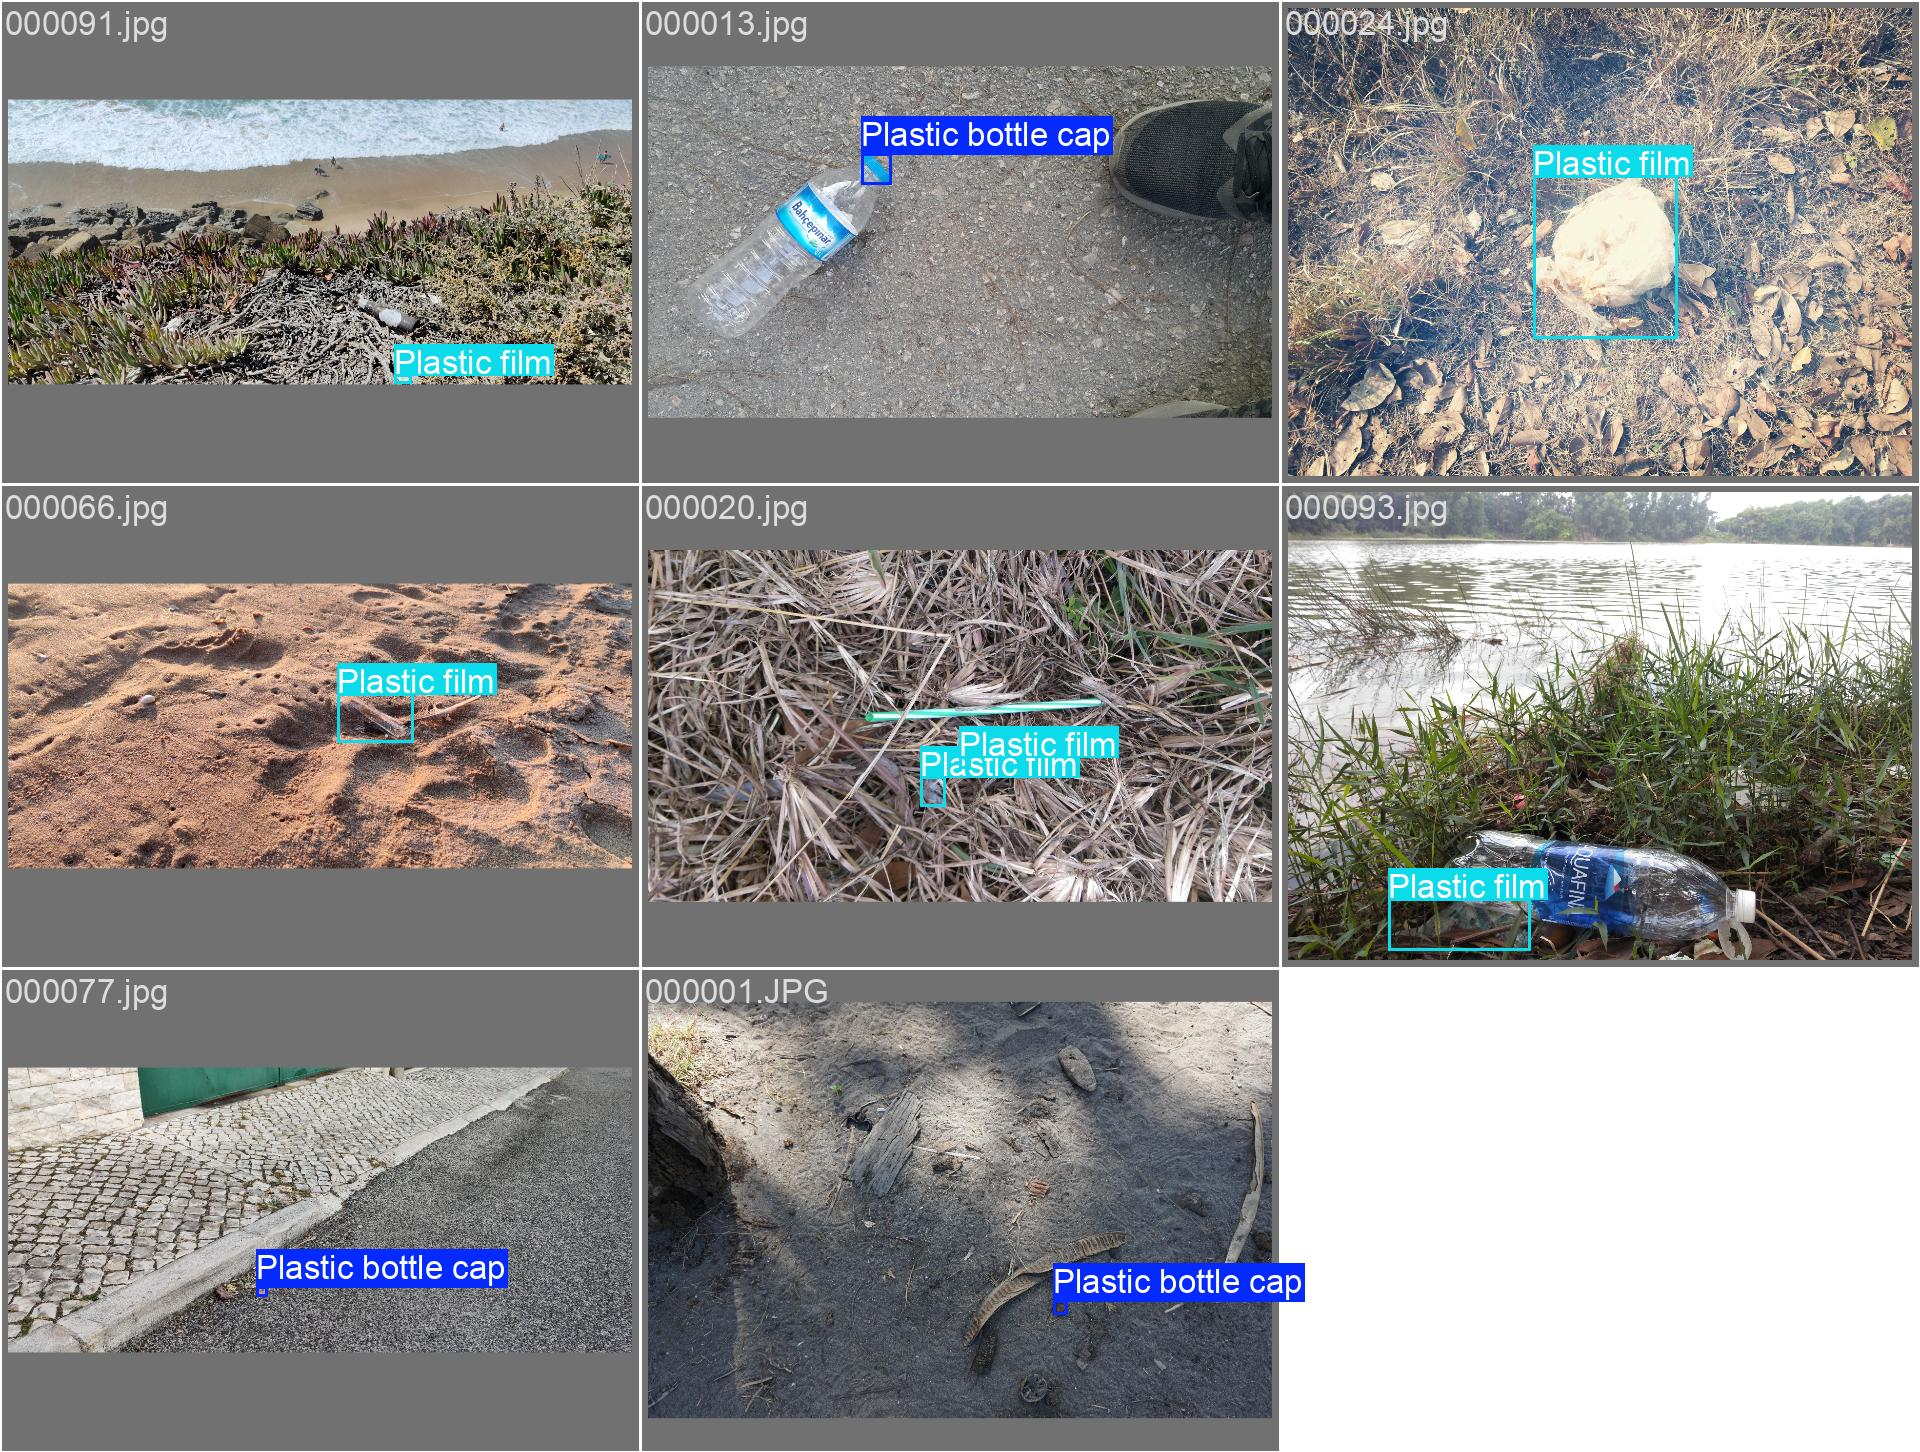

/content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280/val_batch0_pred.jpg


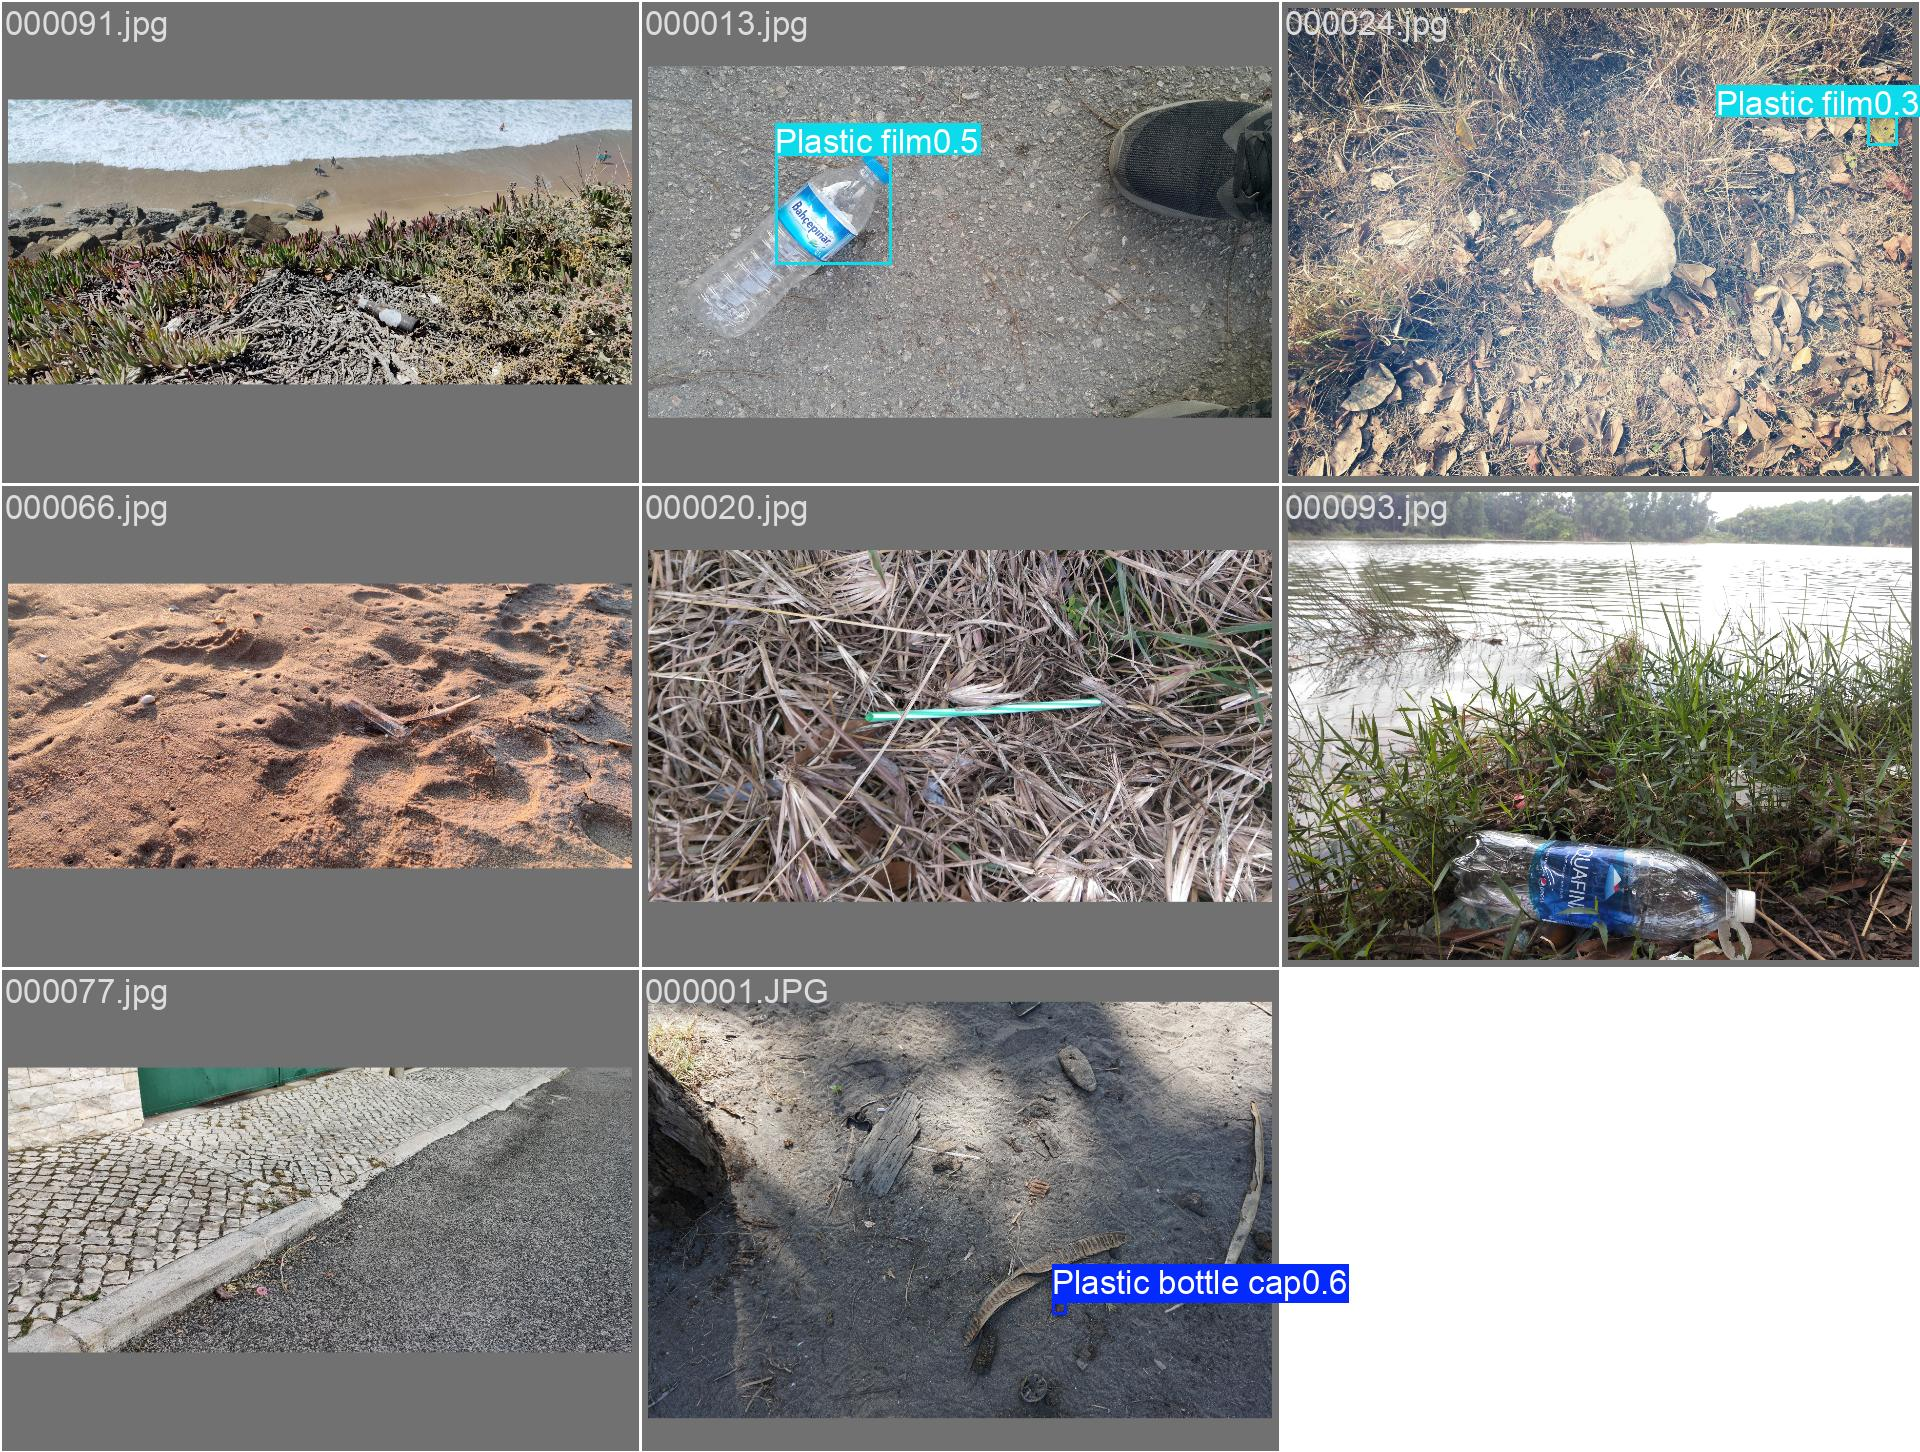

In [12]:
YOLO11L_CANDIDATE_RUN_DIRS = [
    Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280_finetune"),
    Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_top5_1280"),
]

YOLO11L_RUN_DIR = next(
    (run_dir for run_dir in YOLO11L_CANDIDATE_RUN_DIRS if (run_dir / "results.csv").exists()),
    YOLO11L_CANDIDATE_RUN_DIRS[-1],
)

print(f"Visualizing run: {YOLO11L_RUN_DIR}")

yolo11l_results_df = load_yolo_results(YOLO11L_RUN_DIR)
print_best_yolo_metrics(yolo11l_results_df)
plot_yolo_training_curves(yolo11l_results_df, title="YOLO11l top-5")
display_yolo_artifacts(YOLO11L_RUN_DIR)

#### Observations

The YOLO11l top-5 experiment reaches approximately `Precision = 0.592`, `Recall = 0.497`, `mAP@0.5 = 0.502`, and `mAP@0.5:0.95 = 0.350`. This confirms that the project target of `mAP@0.5 >= 0.5` is reachable when the class space is simplified.

The improvement over YOLO11m is most visible in `mAP@0.5`, which means the larger model and reduced taxonomy produce more correct detections at the standard IoU threshold. However, `mAP@0.5:0.95` remains lower than `mAP@0.5`, so tight localization is still difficult. The remaining bottleneck is likely small object size, cluttered scenes, and bounding-box precision rather than only class confusion.

This model is the strongest detection result in the notebook. It is not directly comparable to the 17-class model as a full replacement, because it solves a reduced top-5 task, but it is valuable evidence that class simplification significantly improves detection quality.

## 10 Classes With Full Merging

This experiment maps every original TACO category into one of 10 merged groups, preserving all images and annotations. It tests whether a complete 10-class taxonomy can keep the task realistic while reducing class granularity. This is harder than top-5 because noisy and visually diverse objects are still included.

In [17]:
with open(Path(TACO_DIR) / "annotations.json", "r") as f:
      coco = json.load(f)

category_names = sorted([c["name"] for c in coco["categories"]])

for name in category_names:
    print(name)

Aerosol
Aluminium blister pack
Aluminium foil
Battery
Broken glass
Carded blister pack
Cigarette
Clear plastic bottle
Corrugated carton
Crisp packet
Disposable food container
Disposable plastic cup
Drink can
Drink carton
Egg carton
Foam cup
Foam food container
Food Can
Food waste
Garbage bag
Glass bottle
Glass cup
Glass jar
Magazine paper
Meal carton
Metal bottle cap
Metal lid
Normal paper
Other carton
Other plastic
Other plastic bottle
Other plastic container
Other plastic cup
Other plastic wrapper
Paper bag
Paper cup
Paper straw
Pizza box
Plastic bottle cap
Plastic film
Plastic glooves
Plastic lid
Plastic straw
Plastic utensils
Plastified paper bag
Polypropylene bag
Pop tab
Rope & strings
Scrap metal
Shoe
Single-use carrier bag
Six pack rings
Spread tub
Squeezable tube
Styrofoam piece
Tissues
Toilet tube
Tupperware
Unlabeled litter
Wrapping paper


### Assemble Classification

The mapping below assigns each original TACO class to one of 10 target groups. This version is complete: no source category is intentionally dropped, so the resulting dataset keeps the full training and validation image set.

In [6]:
TACO_DIR = Path(
    "/content/taco"
)
YOLO_MERGED10_DIR = Path("/content/taco_yolo_merged10")


missing_classes = [
      "Aerosol",
      "Aluminium blister pack",
      "Battery",
      "Carded blister pack",
      "Cigarette",
      "Disposable food container",
      "Food waste",
      "Other plastic",
      "Other plastic container",
      "Plastic glooves",
      "Plastic lid",
      "Plastic straw",
      "Plastic utensils",
      "Rope & strings",
      "Shoe",
      "Six pack rings",
      "Squeezable tube",
      "Tissues",
      "Unlabeled litter",
  ]



MAP_MERGED10 = {
    # 1. cans / metal containers
    "Drink can": "can",
    "Food Can": "can",
    "Aerosol": "can",

    # 2. plastic bottles
    "Clear plastic bottle": "plastic_bottle",
    "Other plastic bottle": "plastic_bottle",

    # 3. bottle caps / lids
    "Plastic bottle cap": "cap_lid",
    "Metal bottle cap": "cap_lid",
    "Plastic lid": "cap_lid",
    "Metal lid": "cap_lid",
    "Pop tab": "cap_lid",

    # 4. cups / containers
    "Disposable plastic cup": "cup_container",
    "Paper cup": "cup_container",
    "Foam cup": "cup_container",
    "Glass cup": "cup_container",
    "Other plastic cup": "cup_container",
    "Disposable food container": "cup_container",
    "Foam food container": "cup_container",
    "Other plastic container": "cup_container",
    "Spread tub": "cup_container",
    "Tupperware": "cup_container",

    # 5. plastic film / wrappers / bags
    "Plastic film": "plastic_film_wrapper",
    "Other plastic wrapper": "plastic_film_wrapper",
    "Single-use carrier bag": "plastic_film_wrapper",
    "Polypropylene bag": "plastic_film_wrapper",
    "Crisp packet": "plastic_film_wrapper",
    "Garbage bag": "plastic_film_wrapper",
    "Six pack rings": "plastic_film_wrapper",
    "Other plastic": "plastic_film_wrapper",

    # 6. carton / paperboard
    "Drink carton": "carton",
    "Corrugated carton": "carton",
    "Egg carton": "carton",
    "Meal carton": "carton",
    "Other carton": "carton",
    "Pizza box": "carton",
    "Toilet tube": "carton",

    # 7. paper
    "Normal paper": "paper",
    "Magazine paper": "paper",
    "Wrapping paper": "paper",
    "Paper bag": "paper",
    "Plastified paper bag": "paper",
    "Tissues": "paper",

    # 8. glass
    "Glass bottle": "glass",
    "Glass jar": "glass",
    "Broken glass": "glass",

    # 9. small metal / foil / blister
    "Scrap metal": "small_metal",
    "Aluminium foil": "small_metal",
    "Aluminium blister pack": "small_metal",
    "Carded blister pack": "small_metal",

    # 10. small litter / miscellaneous
    "Styrofoam piece": "small_litter",
    "Battery": "small_litter",
    "Cigarette": "small_litter",
    "Food waste": "small_litter",
    "Plastic glooves": "small_litter",
    "Plastic straw": "small_litter",
    "Paper straw": "small_litter",
    "Plastic utensils": "small_litter",
    "Rope & strings": "small_litter",
    "Shoe": "small_litter",
    "Squeezable tube": "small_litter",
    "Unlabeled litter": "small_litter",
}

In [7]:
with open(Path(TACO_DIR) / "annotations.json", "r") as f:
    coco = json.load(f)

all_category_names = sorted(c["name"] for c in coco["categories"])

missing = sorted(set(all_category_names) - set(MAP_MERGED10))
extra = sorted(set(MAP_MERGED10) - set(all_category_names))

print("Missing:", missing)
print("Extra:", extra)
print("Mapped classes:", sorted(set(MAP_MERGED10.values())))
print("Num merged classes:", len(set(MAP_MERGED10.values())))

Missing: []
Extra: []
Mapped classes: ['can', 'cap_lid', 'carton', 'cup_container', 'glass', 'paper', 'plastic_bottle', 'plastic_film_wrapper', 'small_litter', 'small_metal']
Num merged classes: 10


### Convert to YOLO Format

The converted dataset keeps all images and all annotations while replacing fine-grained labels with merged class names. This makes the task less fragmented than the original taxonomy but still substantially harder than filtered top-5/top-10 experiments.

In [11]:
yaml_path_merged10 = convert_taco_to_yolo(
    taco_dir=TACO_DIR,
    output_dir=YOLO_MERGED10_DIR,
    category_mapping=MAP_MERGED10,
    train_fraction=0.8,
    seed=42,
    image_mode="copy",
    drop_other=False,
    drop_empty_images=False,
)

print(Path(yaml_path_merged10).read_text())

Classes: ['can', 'cap_lid', 'carton', 'cup_container', 'glass', 'paper', 'plastic_bottle', 'plastic_film_wrapper', 'small_litter', 'small_metal']
Train images before filtering: 1200
Val images before filtering: 300
Written images: 1500
Written annotations: 4784
Skipped invalid boxes: 0
Skipped empty images: 0
YAML: /content/taco_yolo_merged10/taco.yaml
path: "/content/taco_yolo_merged10"
train: images/train
val: images/val
names:
  0: "can"
  1: "cap_lid"
  2: "carton"
  3: "cup_container"
  4: "glass"
  5: "paper"
  6: "plastic_bottle"
  7: "plastic_film_wrapper"
  8: "small_litter"
  9: "small_metal"



### Train

The training stage contains a short smoke test and then a full run. The smoke test verifies that the converted top-5 dataset is valid, while the full run searches for the best checkpoint with the larger YOLO11l model.

#### Smoke Test

The smoke run checks whether the merged-10 dataset can be trained with YOLO11l and the selected image size. Its metrics are not used as final quality; it is a quick pipeline and memory check.

In [12]:
smoke_model = YOLO("yolo11l.pt")

smoke_results = smoke_model.train(
    data=str(yaml_path_merged10),
    epochs=3,
    imgsz=1280,
    batch=4,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/yolo_runs",
    name="yolo11l_top10_smoke",
    plots=True,
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/taco_yolo_merged10/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11l_top10_smoke-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=

#### Full Training

The full run trains YOLO11l on the complete merged-10 dataset. Since this setup preserves all difficult objects, training is slower and early mAP can be much lower than in filtered datasets.

In [ ]:
model = YOLO("/content/yolo_runs/yolo11l_top10_smoke/weights/best.pt")

results = model.train(
    data=str(yaml_path_merged10),
    epochs=80,
    imgsz=1280,
    batch=4,
    patience=15,
    optimizer="AdamW",
    lr0=5e-4,
    lrf=0.05,
    cos_lr=True,
    warmup_epochs=0,
    warmup_bias_lr=0.0,
    close_mosaic=10,
    amp=True,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/drive/MyDrive/taco_yolo_runs",
    name="yolo11l_top10_1280",
    save_period=5,
    exist_ok=True,
    save=True,
    plots=True,
)

print("Saved to:", results.save_dir)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/taco_yolo_merged10/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo_runs/yolo11l_top10_smoke/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11l_top10_1280, nbs=64, nms=Fal

      30/80      12.4G     0.9762      2.131      1.264         38       1280: 35% ━━━━──────── 105/300 2.8it/s 38.7s<1:09

: 

#### Validate

The best checkpoint is evaluated with fixed validation settings. These values are used to compare the full merged-10 formulation against filtered exact top-10 and top-5 runs.

In [ ]:
run_dir = Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_top10_1280")
best_model = YOLO(str(run_dir / "weights" / "best.pt"))

metrics = best_model.val(
    data=str(yaml_path_merged10),
    imgsz=1280,
    batch=4,
    conf=0.001,
    iou=0.7,
    max_det=300,
    device=0,
    plots=True,
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,282,396 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4133.8±538.2 MB/s, size: 1851.6 KB)
val: Scanning /content/taco_yolo_top10/labels/val/batch_1.cache... 120 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 45.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 9.6it/s 3.1s<0.1s
                   all        120        166      0.591      0.413      0.425      0.306
          Glass bottle         17         25      0.835       0.32      0.429      0.342
    Plastic bottle cap         39         45      0.609      0.667      0.591      0.431
          Plastic film         50         69      0.348      0.406      0.397      0.275
               Pop tab         18         27      0.571      0.259      0.286      0.177
Speed: 3.3

#### Fine-Tune

This low-learning-rate stage tests whether the full merged-10 model can be improved after the main run. Augmentations are disabled to focus on stable localization and reduce late-stage training noise.

In [ ]:
model = YOLO("/content/drive/MyDrive/taco_yolo_runs/yolo11l_top10_1280/weights/best.pt")

results = model.train(
    data=str(yaml_path_top10),
    epochs=30,
    imgsz=1280,
    batch=4,
    patience=8,
    optimizer="AdamW",
    lr0=5e-5,
    lrf=0.1,
    warmup_epochs=0,
    warmup_bias_lr=0.0,
    cos_lr=True,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    close_mosaic=0,
    amp=True,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/drive/MyDrive/taco_yolo_runs",
    name="yolo11l_top10_1280_finetune",
    save_period=1,
    exist_ok=True,
    save=True,
    plots=True,
)

print("Saved to:", results.save_dir)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/taco_yolo_top10/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/taco_yolo_runs/yolo11l_top10_1280/weights/best.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolo11l_top10_1280_fine

#### Validate Fine-Tuning

The fine-tuned checkpoint is validated with the same settings as the main run. The comparison shows whether additional low-learning-rate training provides meaningful gains.

In [25]:
run_dir = Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_top10_1280_finetune")
best_model = YOLO(str(run_dir / "weights" / "best.pt"))

metrics = best_model.val(
    data=str(yaml_path_top10),
    imgsz=1280,
    batch=4,
    conf=0.001,
    iou=0.7,
    max_det=300,
    device=0,
    plots=True,
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,282,396 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4535.1±897.5 MB/s, size: 1851.6 KB)
val: Scanning /content/taco_yolo_top10/labels/val/batch_1.cache... 120 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 55.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 10.8it/s 2.8s0.1s
                   all        120        166      0.563      0.386      0.419      0.301
          Glass bottle         17         25      0.725       0.28      0.362      0.298
    Plastic bottle cap         39         45      0.629      0.578      0.624      0.442
          Plastic film         50         69      0.399      0.464      0.431      0.308
               Pop tab         18         27      0.498       0.22       0.26      0.156
Speed: 3.5

#### Visualize

The visualization reads the saved Ultralytics run directory, plots metric/loss curves from `results.csv`, and displays generated validation artifacts such as confusion matrices, PR curves, and predicted validation batches.

In [ ]:
MERGED10_RUN_DIRS = [
    Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_merged10_1536_finetune"),
    Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_merged10_1536"),
    Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_merged10_1280_clean"),
    Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_top10_1280"),
]

MERGED10_RUN_DIR = next(
    (run_dir for run_dir in MERGED10_RUN_DIRS if (run_dir / "results.csv").exists()),
    MERGED10_RUN_DIRS[-1],
)

print(f"Visualizing run: {MERGED10_RUN_DIR}")

merged10_results_df = load_yolo_results(MERGED10_RUN_DIR)
print_best_yolo_metrics(merged10_results_df)
plot_yolo_training_curves(merged10_results_df, title="YOLO11l full merged-10")
display_yolo_artifacts(MERGED10_RUN_DIR)


#### Observations

The full merged-10 setup is significantly harder than filtered top-5/top-10 because it preserves all 1500 images and all 4784 annotations. The plots should be interpreted with this in mind: lower mAP does not necessarily mean the model is broken, but rather that the task contains many noisy and visually diverse categories.

If the validation quality curve stays far below the filtered top-10 results, the conclusion is that preserving all categories in broad merged groups does not solve the class/noise problem. It makes the task more realistic, but it does not reach the project target of `mAP@0.5 >= 0.5`.

## Top-10 Classes Without Merging

This experiment keeps 10 exact TACO category names and drops all other categories. It is a filtered task: only images containing selected objects remain. The goal is to test whether a larger taxonomy than top-5 can still approach the `mAP@0.5 >= 0.5` target.

### Assemble Classification

The selected exact top-10 classes expand the successful top-5 setup without merging labels. Each target class remains an original TACO category name. This keeps the labels more specific than the merged experiments, while still dropping all categories outside the selected set.

In [16]:
TACO_DIR = Path(
    "/content/taco"
)

YOLO_TOP10_FILTERED_DIR = Path("/content/taco_yolo_top10_filtered")

SELECTED_TOP10_CLASSES = [
    # plastic bottle group
    "Clear plastic bottle",
    "Other plastic bottle",

    # caps
    "Plastic bottle cap",
    "Metal bottle cap",

    # cups
    "Disposable plastic cup",
    "Paper cup",

    # plastic film / wrappers
    "Plastic film",
    "Other plastic wrapper",

    # cans
    "Drink can",
    "Food Can",
]

MAP_TOP10_FILTERED = {
    class_name: class_name
    for class_name in SELECTED_TOP10_CLASSES
}

### Convert Dataset to YOLO Format

Only the selected exact top-10 categories are kept. All other objects are removed, and images without remaining annotations are skipped. This makes the dataset smaller and easier than the complete merged-10 setup, but harder than top-5.

In [17]:
yaml_path_top10_filtered = convert_taco_to_yolo(
    taco_dir=TACO_DIR,
    output_dir=YOLO_TOP10_FILTERED_DIR,
    category_mapping=MAP_TOP10_FILTERED,
    train_fraction=0.8,
    seed=42,
    image_mode="copy",
    drop_other=True,
    drop_empty_images=True,
)

print(Path(yaml_path_top10_filtered).read_text())

Classes: ['Clear plastic bottle', 'Disposable plastic cup', 'Drink can', 'Food Can', 'Metal bottle cap', 'Other plastic bottle', 'Other plastic wrapper', 'Paper cup', 'Plastic bottle cap', 'Plastic film']
Train images before filtering: 1200
Val images before filtering: 300
Written images: 986
Written annotations: 1769
Skipped invalid boxes: 0
Skipped empty images: 514
YAML: /content/taco_yolo_top10_filtered/taco.yaml
path: "/content/taco_yolo_top10_filtered"
train: images/train
val: images/val
names:
  0: "Clear plastic bottle"
  1: "Disposable plastic cup"
  2: "Drink can"
  3: "Food Can"
  4: "Metal bottle cap"
  5: "Other plastic bottle"
  6: "Other plastic wrapper"
  7: "Paper cup"
  8: "Plastic bottle cap"
  9: "Plastic film"



In [8]:
import json

with open(YOLO_TOP10_FILTERED_DIR / "split.json", "r") as f:
    manifest = json.load(f)

print("Classes:", manifest["classes"])
print("Num classes:", len(manifest["classes"]))
print("Written images:", manifest["written_images"])
print("Written annotations:", manifest["written_annotations"])
print("Skipped empty images:", manifest["skipped_empty_images"])

Classes: ['Clear plastic bottle', 'Disposable plastic cup', 'Drink can', 'Food Can', 'Metal bottle cap', 'Other plastic bottle', 'Other plastic wrapper', 'Paper cup', 'Plastic bottle cap', 'Plastic film']
Num classes: 10
Written images: 986
Written annotations: 1769
Skipped empty images: 514


### Train

The training stage for exact top-10 repeats the same structure as the top-5 experiment: a short smoke test followed by a full YOLO11l run and a low-learning-rate fine-tune. This makes it possible to compare whether expanding from 5 to 10 exact classes preserves enough detection quality.

#### Smoke Test

The smoke test verifies that the filtered exact top-10 dataset is valid and that YOLO11l can read the labels, train, and validate without conversion errors. Its metrics are used only as a sanity check.

In [11]:
smoke_model = YOLO("yolo11l.pt")

smoke_results = smoke_model.train(
    data=str(yaml_path_top10_filtered),
    epochs=3,
    imgsz=1280,
    batch=4,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/yolo_runs",
    name="yolo11l_top10_filtered_smoke",
    plots=True,
)

print("Smoke saved to:", smoke_results.save_dir)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/taco_yolo_top10_filtered/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11l_top10_filtered_smoke, nbs=64, nms=False, opset=None, optimize=Fals

#### Full Training

YOLO11l is trained from the pretrained base checkpoint on the filtered exact top-10 dataset. This avoids carrying over a checkpoint trained with a different class mapping and keeps the comparison clean.

In [14]:
from ultralytics import YOLO

model = YOLO("yolo11l.pt")

results = model.train(
    data=str(yaml_path_top10_filtered),
    epochs=80,
    imgsz=1280,
    batch=4,
    patience=15,
    optimizer="AdamW",
    lr0=5e-4,
    lrf=0.05,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/drive/MyDrive/taco_yolo_runs",
    name="yolo11l_top10_filtered_1280",
    save_period=5,
    exist_ok=True,
    save=True,
    plots=True,
)

print("Saved to:", results.save_dir)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/taco_yolo_top10_filtered/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11l_top10_filtered_1280, nbs=64, nms=False, opset=None, optimize=Fals

#### Validate

The best full-training checkpoint is evaluated on the filtered exact top-10 validation split. This establishes the main top-10 baseline before low-learning-rate fine-tuning.

In [16]:
run_dir = Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_top10_filtered_1280")
best_model = YOLO(str(run_dir / "weights" / "best.pt"))

metrics = best_model.val(
    data=str(yaml_path_top10_filtered),
    imgsz=1280,
    batch=4,
    conf=0.001,
    iou=0.7,
    max_det=300,
    device=0,
    plots=True,
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,287,022 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3763.2±717.9 MB/s, size: 1193.5 KB)
val: Scanning /content/taco_yolo_top10_filtered/labels/val/batch_1.cache... 191 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 191/191 80.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 10.3it/s 4.6s0.1s
                   all        191        318      0.409      0.452      0.416      0.334
  Clear plastic bottle         41         48       0.56      0.729      0.734      0.638
Disposable plastic cup         20         24      0.368      0.417      0.434      0.376
             Drink can         32         46      0.549      0.674      0.553      0.448
              Food Can          7         11      0.608      0.818       0.76       0.67
 

#### Fine-Tuning

The fine-tuning stage starts from the best exact top-10 checkpoint and uses a lower learning rate with heavy augmentations disabled. The goal is to check whether the already trained model can gain a few points in localization or recall without a full retraining cycle.

In [17]:
model = YOLO(
    "/content/drive/MyDrive/taco_yolo_runs/"
    "yolo11l_top10_filtered_1280/weights/best.pt"
)

results = model.train(
    data=str(yaml_path_top10_filtered),
    epochs=40,
    imgsz=1280,
    batch=4,
    patience=10,
    optimizer="AdamW",
    lr0=5e-5,
    lrf=0.1,
    warmup_epochs=0,
    warmup_bias_lr=0.0,
    cos_lr=True,
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    close_mosaic=0,
    amp=True,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/drive/MyDrive/taco_yolo_runs",
    name="yolo11l_top10_filtered_1280_finetune",
    save_period=1,
    exist_ok=True,
    save=True,
    plots=True,
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/taco_yolo_top10_filtered/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/taco_yolo_runs/yolo11l_top10_filtered_1280/weights/best.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=yolo1

#### Validate Fine-Tuning

The fine-tuned exact top-10 checkpoint is evaluated with the same validation settings as the full run. This determines whether the additional training produced a meaningful improvement.

In [18]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/MyDrive/taco_yolo_runs/"
    "yolo11l_top10_filtered_1280_finetune/weights/best.pt"
)

metrics = best_model.val(
    data=str(yaml_path_top10_filtered),
    imgsz=1280,
    batch=4,
    conf=0.001,
    iou=0.7,
    max_det=300,
    device=0,
    plots=True,
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,287,022 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3643.1±855.7 MB/s, size: 1269.8 KB)
val: Scanning /content/taco_yolo_top10_filtered/labels/val/batch_1.cache... 191 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 191/191 80.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 11.7it/s 4.1s0.1s
                   all        191        318      0.456      0.432      0.418      0.345
  Clear plastic bottle         41         48      0.555      0.708      0.732       0.66
Disposable plastic cup         20         24      0.382      0.333      0.459      0.428
             Drink can         32         46      0.593      0.609      0.505      0.421
              Food Can          7         11      0.798      0.818      0.779      0.689
 

#### Visualize

The visualization reads the saved Ultralytics run directory, plots metric/loss curves from `results.csv`, and displays generated validation artifacts such as confusion matrices, PR curves, and predicted validation batches.

In [ ]:
TOP10_RUN_DIRS = [
    Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_top10_filtered_1280_finetune"),
    Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_top10_filtered_1280"),
]

TOP10_RUN_DIR = next(
    (run_dir for run_dir in TOP10_RUN_DIRS if (run_dir / "results.csv").exists()),
    TOP10_RUN_DIRS[-1],
)

print(f"Visualizing run: {TOP10_RUN_DIR}")

top10_results_df = load_yolo_results(TOP10_RUN_DIR)
print_best_yolo_metrics(top10_results_df)
plot_yolo_training_curves(top10_results_df, title="YOLO11l exact filtered top-10")
display_yolo_artifacts(TOP10_RUN_DIR)


#### Observations

The exact filtered top-10 model improves over the full merged-10 formulation because unrelated objects are removed from both training and validation. The plots should show substantially better validation quality than the complete merged-10 run, but the curve still saturates below the target.

The final fine-tuned score is approximately `mAP@0.5 = 0.418` and `mAP@0.5:0.95 = 0.345`. Fine-tuning mainly improves tighter-box quality (`mAP@0.5:0.95`) and provides almost no gain in `mAP@0.5`, which suggests that this exact top-10 taxonomy is near its practical limit for YOLO11l.

# Top-10 Filtered Merged Categories

This experiment combines the two previous ideas: it keeps 10 semantic groups, but filters out unrelated/noisy categories instead of preserving the full dataset. The goal is to reduce class confusion while keeping more semantic coverage than the top-5 setup.

## Assemble Categories

The mapping groups visually related exact TACO categories into 10 target labels. Unlike full merged-10, this mapping is intentionally partial: categories outside the selected groups are dropped from the experiment.

In [8]:
from pathlib import Path
import json

YOLO_FILTERED_MERGED10_DIR = Path("/content/taco_yolo_filtered_merged10")

TACO_DIR = Path(
    "/content/taco"
)

MAP_FILTERED_MERGED10 = {
    # 1. plastic bottles
    "Clear plastic bottle": "plastic_bottle",
    "Other plastic bottle": "plastic_bottle",

    # 2. bottle caps
    "Plastic bottle cap": "bottle_cap",
    "Metal bottle cap": "bottle_cap",

    # 3. cups
    "Disposable plastic cup": "cup",
    "Paper cup": "cup",
    "Foam cup": "cup",
    "Glass cup": "cup",
    "Other plastic cup": "cup",

    # 4. plastic film / wrappers / bags
    "Plastic film": "plastic_film_wrapper",
    "Other plastic wrapper": "plastic_film_wrapper",
    "Single-use carrier bag": "plastic_film_wrapper",
    "Polypropylene bag": "plastic_film_wrapper",
    "Crisp packet": "plastic_film_wrapper",
    "Garbage bag": "plastic_film_wrapper",

    # 5. cans
    "Drink can": "can",
    "Food Can": "can",

    # 6. cartons
    "Drink carton": "carton",
    "Corrugated carton": "carton",
    "Egg carton": "carton",
    "Meal carton": "carton",
    "Other carton": "carton",
    "Pizza box": "carton",

    # 7. paper
    "Normal paper": "paper",
    "Magazine paper": "paper",
    "Wrapping paper": "paper",
    "Paper bag": "paper",
    "Plastified paper bag": "paper",

    # 8. glass
    "Glass bottle": "glass",
    "Glass jar": "glass",

    # 9. small metal
    "Pop tab": "small_metal",
    "Metal lid": "small_metal",
    "Aluminium foil": "small_metal",

    # 10. styrofoam
    "Styrofoam piece": "styrofoam",
    "Foam food container": "styrofoam",
}

In [9]:
with open(Path(TACO_DIR) / "annotations.json", "r") as f:
      coco = json.load(f)

all_category_names = sorted(c["name"] for c in coco["categories"])

mapped_source_classes = sorted(set(MAP_FILTERED_MERGED10))
dropped_classes = sorted(set(all_category_names) - set(MAP_FILTERED_MERGED10))
merged_classes = sorted(set(MAP_FILTERED_MERGED10.values()))

print("Mapped source classes:", len(mapped_source_classes))
print(mapped_source_classes)

print("\nDropped source classes:", len(dropped_classes))
print(dropped_classes)

print("\nMerged target classes:", len(merged_classes))
print(merged_classes)

Mapped source classes: 35
['Aluminium foil', 'Clear plastic bottle', 'Corrugated carton', 'Crisp packet', 'Disposable plastic cup', 'Drink can', 'Drink carton', 'Egg carton', 'Foam cup', 'Foam food container', 'Food Can', 'Garbage bag', 'Glass bottle', 'Glass cup', 'Glass jar', 'Magazine paper', 'Meal carton', 'Metal bottle cap', 'Metal lid', 'Normal paper', 'Other carton', 'Other plastic bottle', 'Other plastic cup', 'Other plastic wrapper', 'Paper bag', 'Paper cup', 'Pizza box', 'Plastic bottle cap', 'Plastic film', 'Plastified paper bag', 'Polypropylene bag', 'Pop tab', 'Single-use carrier bag', 'Styrofoam piece', 'Wrapping paper']

Dropped source classes: 25
['Aerosol', 'Aluminium blister pack', 'Battery', 'Broken glass', 'Carded blister pack', 'Cigarette', 'Disposable food container', 'Food waste', 'Other plastic', 'Other plastic container', 'Paper straw', 'Plastic glooves', 'Plastic lid', 'Plastic straw', 'Plastic utensils', 'Rope & strings', 'Scrap metal', 'Shoe', 'Six pack ring

## Convert to YOLO Format

The conversion keeps only annotations that belong to the filtered merged groups. Images with no remaining selected objects are removed, producing a smaller task focused on the categories most likely to be learnable.

In [10]:
yaml_path_filtered_merged10 = convert_taco_to_yolo(
    taco_dir=TACO_DIR,
    output_dir=YOLO_FILTERED_MERGED10_DIR,
    category_mapping=MAP_FILTERED_MERGED10,
    train_fraction=0.8,
    seed=42,
    image_mode="copy",
    drop_other=True,
    drop_empty_images=True,
)

print(Path(yaml_path_filtered_merged10).read_text())

Classes: ['bottle_cap', 'can', 'carton', 'cup', 'glass', 'paper', 'plastic_bottle', 'plastic_film_wrapper', 'small_metal', 'styrofoam']
Train images before filtering: 1200
Val images before filtering: 300
Written images: 1283
Written annotations: 2711
Skipped invalid boxes: 0
Skipped empty images: 217
YAML: /content/taco_yolo_filtered_merged10/taco.yaml
path: "/content/taco_yolo_filtered_merged10"
train: images/train
val: images/val
names:
  0: "bottle_cap"
  1: "can"
  2: "carton"
  3: "cup"
  4: "glass"
  5: "paper"
  6: "plastic_bottle"
  7: "plastic_film_wrapper"
  8: "small_metal"
  9: "styrofoam"



In [11]:
with open(YOLO_FILTERED_MERGED10_DIR / "split.json", "r") as f:
    manifest = json.load(f)

print("Classes:", manifest["classes"])
print("Num classes:", len(manifest["classes"]))
print("Written images:", manifest["written_images"])
print("Written annotations:", manifest["written_annotations"])
print("Skipped empty images:", manifest["skipped_empty_images"])

print("Train labels:", len(list((YOLO_FILTERED_MERGED10_DIR / "labels/train").glob("**/*.txt"))))
print("Val labels:", len(list((YOLO_FILTERED_MERGED10_DIR / "labels/val").glob("**/*.txt"))))

Classes: ['bottle_cap', 'can', 'carton', 'cup', 'glass', 'paper', 'plastic_bottle', 'plastic_film_wrapper', 'small_metal', 'styrofoam']
Num classes: 10
Written images: 1283
Written annotations: 2711
Skipped empty images: 217
Train labels: 1034
Val labels: 249


## Train

This run trains YOLO11l on the filtered merged-10 dataset from the pretrained base checkpoint. It tests whether semantic merging can improve over exact top-10 without preserving all noisy objects.

In [25]:
from ultralytics import YOLO

model = YOLO("yolo11l.pt")

results = model.train(
    data=str(yaml_path_filtered_merged10),
    epochs=80,
    imgsz=1280,
    batch=4,
    patience=15,
    optimizer="AdamW",
    lr0=5e-4,
    lrf=0.05,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/drive/MyDrive/taco_yolo_runs",
    name="yolo11l_filtered_merged10_1280",
    save_period=5,
    exist_ok=True,
    save=True,
    plots=True,
)

print("Saved to:", results.save_dir)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/taco_yolo_filtered_merged10/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11l_filtered_merged10_1280, nbs=64, nms=False, opset=None, optimiz

## Validate

The best checkpoint is evaluated with the same validation settings used for the exact top-10 model, allowing direct comparison between exact labels and merged labels.

In [26]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/MyDrive/taco_yolo_runs/"
    "yolo11l_filtered_merged10_1280/weights/best.pt"
)

metrics = best_model.val(
    data=str(yaml_path_filtered_merged10),
    imgsz=1280,
    batch=4,
    conf=0.001,
    iou=0.7,
    max_det=300,
    device=0,
    plots=True,
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11l summary (fused): 191 layers, 25,287,022 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3416.6±296.9 MB/s, size: 1425.0 KB)
val: Scanning /content/taco_yolo_filtered_merged10/labels/val/batch_1.cache... 249 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 249/249 87.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 12.4it/s 5.1s0.2s
                   all        249        488      0.465      0.436      0.411      0.339
            bottle_cap         49         61      0.584      0.443      0.468      0.345
                   can         38         57      0.602      0.596      0.595      0.472
                carton         26         38      0.401      0.447      0.264      0.185
                   cup         38         44      0.469      0.455      0.543      0.50

## Visualize

This visualization shows the filtered merged-10 learning curves and saved Ultralytics artifacts. The key comparison is against the exact filtered top-10 section: if merging helps, the mAP curves should end higher or converge faster.

In [ ]:
FILTERED_MERGED10_RUN_DIR = Path("/content/drive/MyDrive/taco_yolo_runs/yolo11l_filtered_merged10_1280")

print(f"Visualizing run: {FILTERED_MERGED10_RUN_DIR}")

filtered_merged10_results_df = load_yolo_results(FILTERED_MERGED10_RUN_DIR)
print_best_yolo_metrics(filtered_merged10_results_df)
plot_yolo_training_curves(filtered_merged10_results_df, title="YOLO11l filtered merged-10")
display_yolo_artifacts(FILTERED_MERGED10_RUN_DIR)


## Observations

The filtered merged-10 model reaches approximately `Precision = 0.465`, `Recall = 0.436`, `mAP@0.5 = 0.411`, and `mAP@0.5:0.95 = 0.339`. The plots should show that the run learns normally, but converges to nearly the same quality level as exact top-10.

This means semantic merging did not provide the expected advantage. The merged groups reduce some pairwise class confusion, but they also create broader classes with higher internal visual variance. The result is not enough to reach `mAP@0.5 >= 0.5`.

# RT-DETR

RT-DETR is tested as an architecturally different detector. Unlike YOLO, it uses a transformer-based detection pipeline. The purpose of this experiment is to check whether the 10-class limitation is specific to YOLO or is a broader dataset/task limitation.

## Train

RT-DETR-L is trained on the filtered exact top-10 dataset to test a detector architecture that is different from YOLO. This experiment checks whether the top-10 limitation is specific to YOLO-style detectors or comes from the dataset/task itself.

In [ ]:
from ultralytics import RTDETR

model = RTDETR("rtdetr-l.pt")

results = model.train(
    data=str(yaml_path_top10_filtered),  # or yaml_path_filtered_merged10
    epochs=80,
    imgsz=1280,
    batch=4,
    patience=15,
    optimizer="AdamW",
    lr0=1e-4,
    lrf=0.05,
    amp=True,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/drive/MyDrive/taco_yolo_runs",
    name="rtdetr_l_top10_filtered_1280",
    save_period=5,
    exist_ok=True,
    save=True,
    plots=True,
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/taco_yolo_top10_filtered/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_l_top10_filtered_1280, nbs=64, nms=False, opset=None, optimize=F

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/80      11.1G      1.928      3.145      1.131          9       1280: 100% ━━━━━━━━━━━━ 199/199 2.4it/s 1:240.5sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 3.2it/s 7.5s0.1s
                   all        191        318   1.33e-05     0.0101   2.45e-06   4.51e-07

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/80      11.9G      1.955      0.271     0.8363         16       1280: 0% ──────────── 0/199  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/80      11.9G      1.631     0.6175      0.824          8       1280: 100% ━━━━━━━━━━━━ 199/199 2.8it/s 1:120.3sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 7.2it/s 3.3s0.1s
                   all        191        318   9.48e-05     0.0671   8.68e-05   2.15e-05

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/80      11.9G      1.811     0.6634     0.5792          8       1280: 0% ──────────── 0/199  0.4s

...

      16/80      11.9G     0.5905      1.705     0.2232          7       1280: 100% ━━━━━━━━━━━━ 199/199 2.8it/s 1:110.3sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 7.1it/s 3.4s0.1s
                   all        191        318      0.417      0.145     0.0224      0.014

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      17/80      11.9G     0.7986      1.302     0.2347         31       1280: 0% ──────────── 0/199  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      17/80      11.9G     0.5515      1.739     0.2001         10       1280: 64% ━━━━━━━╸──── 128/199 2.8it/s 46.8s<25.2s

      17/80      11.9G     0.5563      1.733       0.21         10       1280: 66% ━━━━━━━╸──── 132/199 2.8it/s 48.2s<24.3s

: 

## Validate

The RT-DETR-L checkpoint is evaluated with the same filtered exact top-10 validation settings. The result is compared directly to YOLO11l top-10 to decide whether RT-DETR is a useful alternative.

In [ ]:
model = RTDETR(
    "/content/drive/MyDrive/taco_yolo_runs/"
    "rtdetr_l_top10_filtered_1280/weights/best.pt"
)

metrics = model.val(
    data=str(yaml_path_top10_filtered),
    imgsz=1280,
    batch=4,
    conf=0.001,
    iou=0.7,
    max_det=300,
    device=0,
    plots=True,
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

## Visualize

The RT-DETR visualization displays the training curves and validation artifacts for the transformer-based detector. A flat or near-zero mAP curve indicates non-convergence and justifies stopping this architecture early.

In [ ]:
RTDETR_RUN_DIR = Path("/content/drive/MyDrive/taco_yolo_runs/rtdetr_l_top10_filtered_1280")

print(f"Visualizing run: {RTDETR_RUN_DIR}")

rtdetr_results_df = load_yolo_results(RTDETR_RUN_DIR)
print_best_yolo_metrics(rtdetr_results_df)
plot_yolo_training_curves(rtdetr_results_df, title="RT-DETR-L filtered top-10")
display_yolo_artifacts(RTDETR_RUN_DIR)


## Observations

RT-DETR did not converge on this setup. Its mAP remained close to zero after many epochs, far below the YOLO11l baseline on the same filtered top-10 task.

The plots should show a flat or very slow validation-quality curve. This indicates that RT-DETR is not a useful direction for this project under the current compute budget and dataset formulation.

# YOLO v11x

YOLO11x is tested as a larger-capacity version of the YOLO11 family. This experiment keeps the exact filtered top-10 dataset and changes only model size, so it directly checks whether more capacity can push the 10-class task toward `mAP@0.5 >= 0.5`.

## Train

YOLO11x is trained on the same exact filtered top-10 dataset as YOLO11l. This isolates model capacity as the tested variable: if YOLO11x improves substantially, then the 10-class task may be capacity-limited rather than data-limited.

In [18]:
model = YOLO("yolo11x.pt")

results = model.train(
    data=str(yaml_path_top10_filtered),
    epochs=80,
    imgsz=1280,
    batch=2,
    patience=15,
    optimizer="AdamW",
    lr0=3e-4,
    lrf=0.05,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    workers=4,
    device=0,
    seed=42,
    deterministic=True,
    project="/content/drive/MyDrive/taco_yolo_runs",
    name="yolo11x_top10_filtered_1280",
    save_period=1,
    exist_ok=True,
    save=True,
    plots=True,
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/taco_yolo_top10_filtered/taco.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.05, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11x_top10_filtered_1280, nbs=64, nms=False, opset=None, optimize=Fals

## Validate

The YOLO11x checkpoint is evaluated with the same validation settings as YOLO11l. This makes the comparison between model sizes direct and avoids changing taxonomy, resolution, or validation thresholds.

In [19]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/drive/MyDrive/taco_yolo_runs/"
    "yolo11x_top10_filtered_1280/weights/best.pt"
)

metrics = best_model.val(
    data=str(yaml_path_top10_filtered),
    imgsz=1280,
    batch=2,
    conf=0.001,
    iou=0.7,
    max_det=300,
    device=0,
    plots=True,
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11x summary (fused): 191 layers, 56,838,574 parameters, 0 gradients, 194.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3856.9±820.5 MB/s, size: 1193.5 KB)
val: Scanning /content/taco_yolo_top10_filtered/labels/val/batch_1.cache... 191 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 191/191 89.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 96/96 17.1it/s 5.6s0.0s
                   all        191        318      0.375      0.467      0.374      0.305
  Clear plastic bottle         41         48      0.566      0.771      0.728      0.634
Disposable plastic cup         20         24      0.446        0.5      0.376      0.338
             Drink can         32         46       0.46      0.565      0.482      0.385
              Food Can          7         11       0.72      0.818      0.744      0.607


## Visualize

The YOLO11x visualization plots training metrics and saved validation artifacts. These plots are used to check whether the larger model learns more slowly, overfits, or genuinely improves over YOLO11l.

In [ ]:
YOLO11X_RUN_DIR = Path("/content/drive/MyDrive/taco_yolo_runs/yolo11x_top10_filtered_1280")

print(f"Visualizing run: {YOLO11X_RUN_DIR}")

yolo11x_results_df = load_yolo_results(YOLO11X_RUN_DIR)
print_best_yolo_metrics(yolo11x_results_df)
plot_yolo_training_curves(yolo11x_results_df, title="YOLO11x exact filtered top-10")
display_yolo_artifacts(YOLO11X_RUN_DIR)


## Observations

YOLO11x increases model capacity, but the final result is worse than YOLO11l on the same exact filtered top-10 setup: approximately `mAP@0.5 = 0.374` and `mAP@0.5:0.95 = 0.305`.

The plots should be read as evidence that simply increasing model size does not solve the dataset limitation. The larger model is heavier, but it does not produce better generalization on this small filtered validation set.

# Common Conclusion

Across all YOLOv11 experiments, the only model that reached the project target of `mAP@0.5 >= 0.5` was the **YOLO11l model trained on the filtered 5-class dataset**. Its best validation result was approximately `mAP@0.5 = 0.502`, which satisfies the target threshold.

Expanding the task to 10 classes consistently reduced performance. Exact filtered top-10, filtered merged top-10, full merged top-10, YOLO11x, and RT-DETR-L did not reach `mAP@0.5 = 0.5`. The experiments show that the main limitation is not only detector architecture, but also dataset complexity: small objects, cluttered scenes, limited examples per class, and ambiguous visual categories strongly affect the metric.

Therefore, the final inference model for this project will use the **YOLO11l 5-class checkpoint**. This choice is pragmatic: it is the strongest validated detector, it reaches the requested `mAP@0.5` threshold, and it provides the most reliable behavior among the tested model and taxonomy configurations.